<a href="https://colab.research.google.com/github/etmcrae/Project-1/blob/main/Emily_Project_1COMPLETE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 1 – To Do List



https://www.canva.com/design/DAGgahe423s/lrAz2Nptj2tgzmH-fTi-7Q/edit

## Problem Definition

1. Write a concise problem definition for the project. Put it in a text field at the top of your Jupyter notebook.



What is the variable and what is the cut off metric for that variable acceptable to recieve 95% pass rate?

## Data Collection

2. Load Pandas, Numpy, and Matplotlib..

1. Load data Train.csv from the Google Drive folder.



In [26]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
train = pd.read_csv('https://ddc-datascience.s3.amazonaws.com/Projects/Project.1-Transactions/Data/Transaction.train.csv')

## Data Cleaning

4. Examine the data using tools we have used in class.

1. If there are data cleaning issues, develop recommendations for how to deal with them.



In [27]:
#this is the backup copy
tcopy = pd.DataFrame(train)


In [28]:
train.head()

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_40,var_41,var_42,var_43,var_44,var_45,var_46,var_47,var_48,var_49
0,0,train_0,0,8.9255,-6.7863,11.9081,5.1187,5.7470,14.0137,0.5745,...,5.4879,-4.7645,3.1531,18.5618,1.7202,25.8398,4.4354,3.9642,3.1364,12.7803
1,1,train_1,0,11.5006,-4.1473,13.8588,5.6208,8.0851,14.0239,8.4135,...,5.7999,5.5378,5.5134,30.2645,11.0752,22.5441,7.6421,7.7214,2.5837,18.3560
2,2,train_2,0,8.6093,-2.7457,12.0805,6.9427,5.9525,14.1929,7.3124,...,5.7690,-7.0927,-5.8234,25.6820,2.4013,23.0866,2.9057,9.7905,1.6704,14.7222
3,3,train_3,0,11.0604,-2.1518,8.9522,5.8428,8.2450,13.8463,11.9704,...,5.3430,-7.1541,11.7134,14.7483,5.6961,-0.4639,4.4666,4.7433,0.7178,17.9697
4,4,train_4,0,9.8369,-1.4834,12.8746,5.9405,7.6784,13.8481,7.8895,...,5.5518,1.4493,2.3705,18.4685,5.1743,11.8503,-1.4905,9.5214,-0.1508,17.9974


In [29]:
len(train)

180000

In [30]:
nulls_counts = train.isnull().sum()
nulls_counts * 1000

,0
Unnamed: 0,0
ID_code,0
target,0
var_0,0
var_1,0
var_2,0
var_3,0
var_4,0
var_5,0
var_6,0


In [31]:
duplicate_rows = train[train.duplicated()]
duplicate_rows

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_40,var_41,var_42,var_43,var_44,var_45,var_46,var_47,var_48,var_49


In [32]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180000 entries, 0 to 179999
Data columns (total 53 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Unnamed: 0  180000 non-null  int64  
 1   ID_code     180000 non-null  object 
 2   target      180000 non-null  int64  
 3   var_0       180000 non-null  float64
 4   var_1       180000 non-null  float64
 5   var_2       180000 non-null  float64
 6   var_3       180000 non-null  float64
 7   var_4       180000 non-null  float64
 8   var_5       180000 non-null  float64
 9   var_6       180000 non-null  float64
 10  var_7       180000 non-null  float64
 11  var_8       180000 non-null  float64
 12  var_9       180000 non-null  float64
 13  var_10      180000 non-null  float64
 14  var_11      180000 non-null  float64
 15  var_12      180000 non-null  float64
 16  var_13      180000 non-null  float64
 17  var_14      180000 non-null  float64
 18  var_15      180000 non-null  float64
 19  va

In [33]:
print(train.iloc[:, :21].describe())

          Unnamed: 0         target          var_0          var_1  \
count  180000.000000  180000.000000  180000.000000  180000.000000   
mean    89999.500000       0.100222      10.678650      -1.630045   
std     51961.668564       0.300297       3.041036       4.050519   
min         0.000000       0.000000       0.408400     -15.043400   
25%     44999.750000       0.000000       8.451675      -4.745600   
50%     89999.500000       0.000000      10.526750      -1.611250   
75%    134999.250000       0.000000      12.756200       1.360225   
max    179999.000000       1.000000      20.315000      10.376800   

               var_2          var_3          var_4          var_5  \
count  180000.000000  180000.000000  180000.000000  180000.000000   
mean       10.712922       5.408688       7.566953      14.024017   
std         2.639146       0.866265       1.235043       0.190038   
min         2.117100       2.347300       3.970500      13.434600   
25%         8.720000       4.7685

In [34]:
print(train.iloc[:,21:39].describe())

              var_18         var_19         var_20         var_21  \
count  180000.000000  180000.000000  180000.000000  180000.000000   
mean        5.347539       5.799587      14.721236       5.621549   
std         1.993530       7.432116       2.300002       7.748588   
min        -1.818300     -18.042200       7.586500     -19.272200   
25%         3.815200       0.703000      13.216875       0.412475   
50%         5.437750       6.071300      14.846150       6.014100   
75%         6.864700      11.444800      16.343000      11.159500   
max        11.350700      30.476900      23.132400      34.563700   

              var_22         var_23         var_24         var_25  \
count  180000.000000  180000.000000  180000.000000  180000.000000   
mean       12.735619      10.996891      -0.746871      14.224538   
std         4.185923       2.765963       1.862151       0.171058   
min        -1.018500       2.819000      -7.280600      13.729000   
25%         9.664675       8.8297

In [35]:
print(train.iloc[:, 39:].describe())

              var_36         var_37         var_38         var_39  \
count  180000.000000  180000.000000  180000.000000  180000.000000   
mean        6.980101      -2.870288      19.320843       2.963064   
std         4.964332       5.455353       5.019303       0.369891   
min        -8.196600     -19.551500       3.816700       1.851200   
25%         3.340800      -7.092725      15.752275       2.698400   
50%         7.006550      -2.632150      19.272750       2.959900   
75%        10.776700       1.321300      23.021875       3.241425   
max        23.242800      12.119300      38.332200       4.220400   

              var_40         var_41         var_42         var_43  \
count  180000.000000  180000.000000  180000.000000  180000.000000   
mean        5.635897      -0.000418      -0.668334      20.208845   
std         0.369629       4.422915       5.968300       7.132446   
min         4.258800     -14.506000     -22.748700      -2.995300   
25%         5.374200      -3.2535

In [36]:
pd.unique(train['target'])
#unique_count_1 = train['1'].nunique(target)
#print(f"Unique values in column '1': {unique_count_1}")
#unique_count_0 = train['0'].nunique(target)
#print(f"Unique values in column '0': {unique_count_0}")

array([0, 1])

In [37]:
pd.unique(train['ID_code'])
unique_count = train['ID_code'].nunique()

print(f"Count of unique values: {unique_count}")

Count of unique values: 180000


In [38]:
train['target'].value_counts()

,count
target,
0,161960
1,18040


In [39]:
18040/180000*100

10.022222222222222

In [40]:
train.pop('ID_code')
train.pop('Unnamed: 0')

,Unnamed: 0
0,0
1,1
2,2
3,3
4,4
...,...
179995,179995
179996,179996
179997,179997
179998,179998


## Exploratory Data Analysis

6. Produce some visual analysis of the data – like plots showing the distributions of all variables. Recall that Gaussian Naive Bayes assumes the predictors are normally distributed. Note: you might have to do multiple plots in groups.

1. NOTE: the ‘target’ column indicates a successful transaction (‘1’) or a no-transaction (‘0’). Verify these are the only values in that column.

1. Check the correlation values between all **predictor columns** to ensure there are no substantial correlations between predictors. This is important to support the decision to classify the ‘target’ using Naïve Bayes.

1. Create two data frames: one with all successful transactions, one with all unsuccessful transactions. **Make sure they are copies and not slices**.





In [41]:
import seaborn as sns

In [42]:
purchased = train[train['target'] == 1]  # Subset where Approved is 1
not_purchased = train[train['target'] == 0]  # Subset where Approved is 0

print(purchased)
print(not_purchased)

        target    var_0   var_1    var_2   var_3   var_4    var_5    var_6  \
13           1  16.3699  1.5934  16.7395  4.8222  8.6978  13.7999   2.7925   
29           1   5.3301 -2.6064  13.1913  5.9064  9.1168  14.0957  12.3335   
63           1   7.7072  0.0183   9.9974  6.0425  6.6710  14.0503   9.0144   
65           1  10.5358 -2.5439   8.7394  5.1584  9.0358  13.6021   4.2864   
71           1   6.7547  2.5973  14.2141  4.2336  9.1282  13.9394   3.6480   
...        ...      ...     ...      ...     ...     ...      ...      ...   
179949       1   8.0020 -0.6347  10.4115  6.6628  7.4319  14.1266   3.2978   
179956       1  12.8143  1.7022  12.5143  5.1252  5.9459  14.0384   1.9840   
179964       1  10.7885 -2.7318   9.9486  5.4815  5.8853  13.6646   0.6277   
179968       1   7.1795 -1.8935  13.6706  4.5245  5.2765  13.9576   8.4353   
179970       1  17.5818 -1.3393  15.3123  6.6506  6.6792  13.8550   4.5367   

          var_7    var_8  ...  var_40   var_41   var_42   var_4

In [43]:
len(purchased)

18040

In [44]:
len(not_purchased)

161960

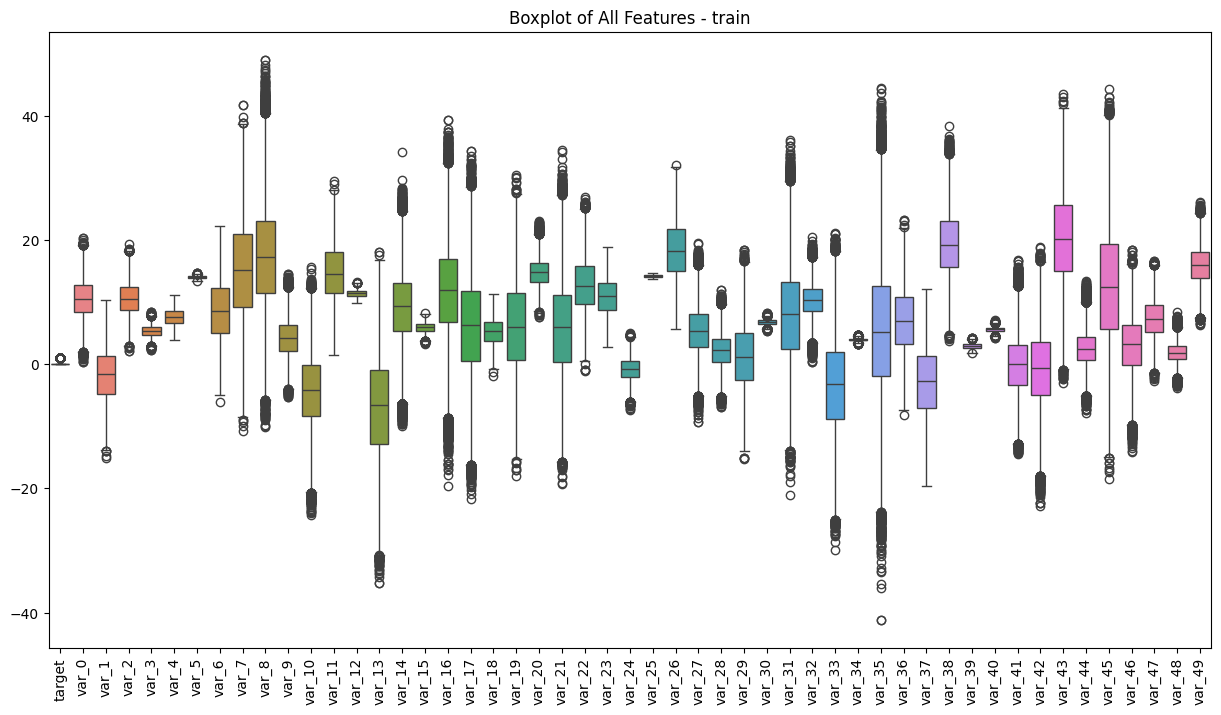

In [45]:
#df = pd.DataFrame(np.random.randn(100, 51), columns=[f'Feature_{i}' for i in range(1, 52)])

# Set up subplots for better visualization
plt.figure(figsize=(15, 8))
sns.boxplot(data=train)
plt.xticks(rotation=90)  # Rotate x-axis labels for readability
plt.title("Boxplot of All Features - train")
plt.savefig('box-whiskers.png')
plt.show()


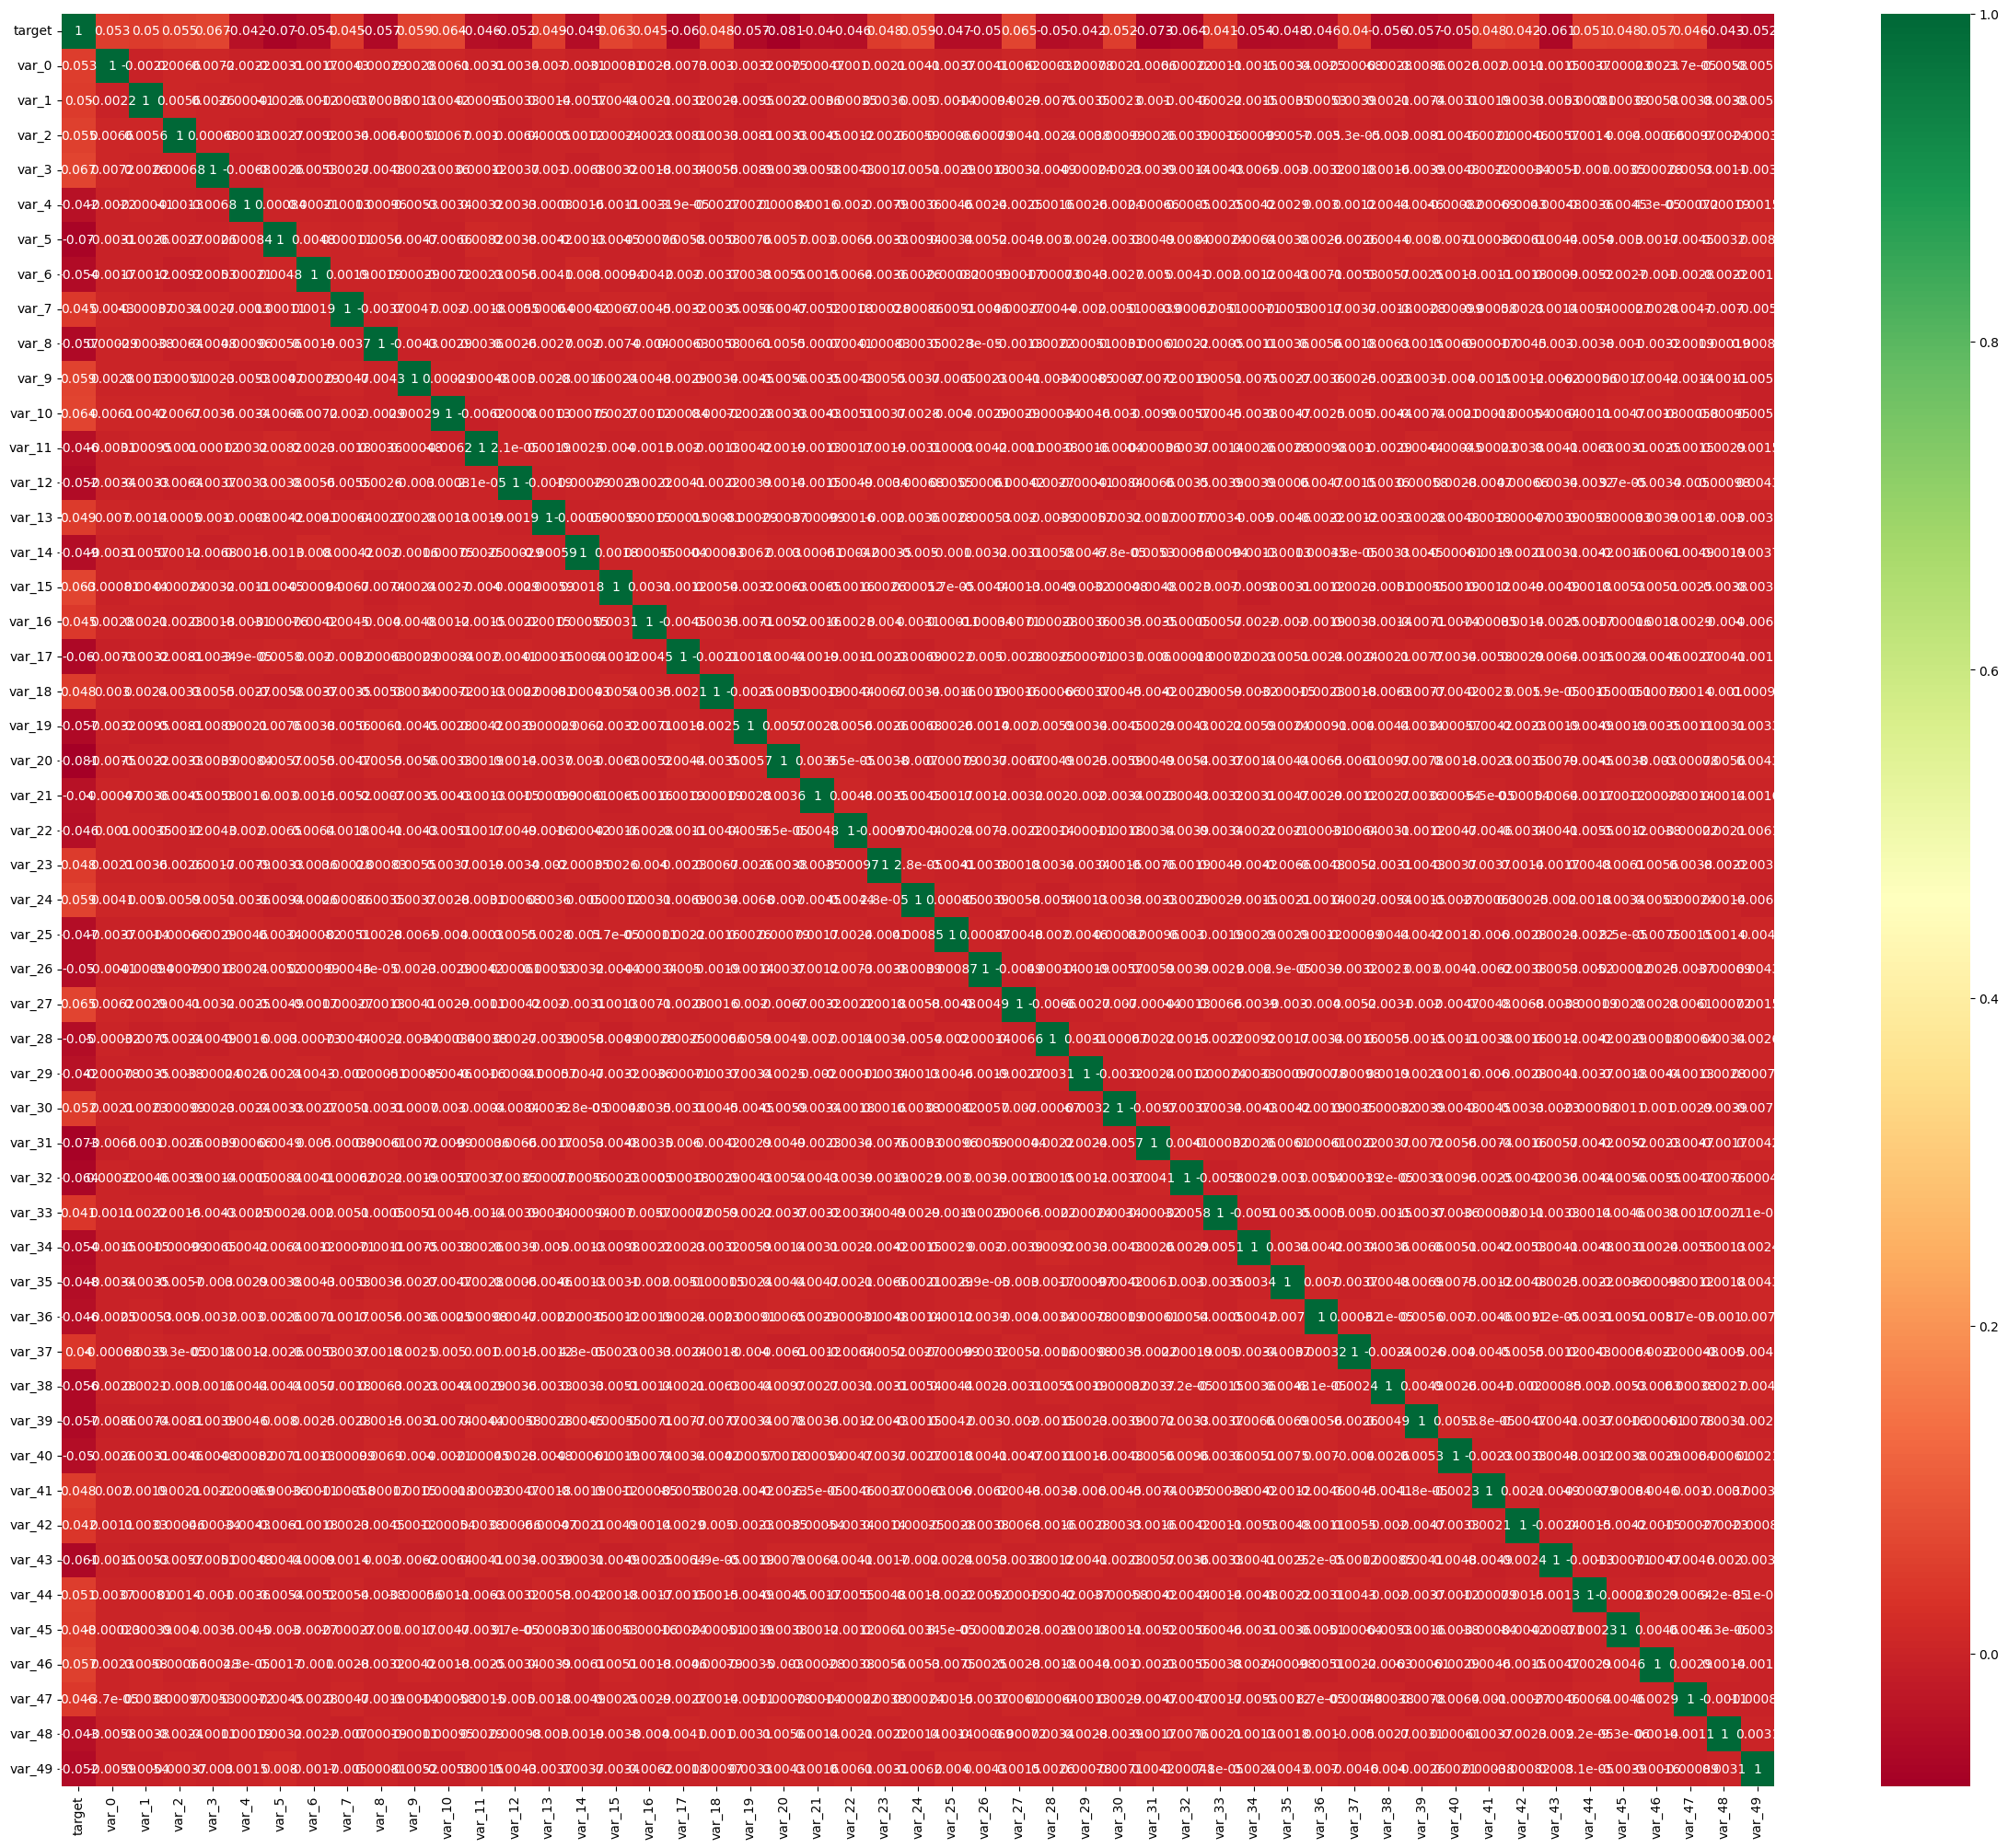

In [46]:
# Correlation Plot
column_correlations = train.corr()
#column_correlations
plt.figure(figsize=(30,25))
sns.heatmap(column_correlations, annot=True, cmap='RdYlGn') ;
plt.savefig('heat-all.png')
#, cmap='RdYlGn'

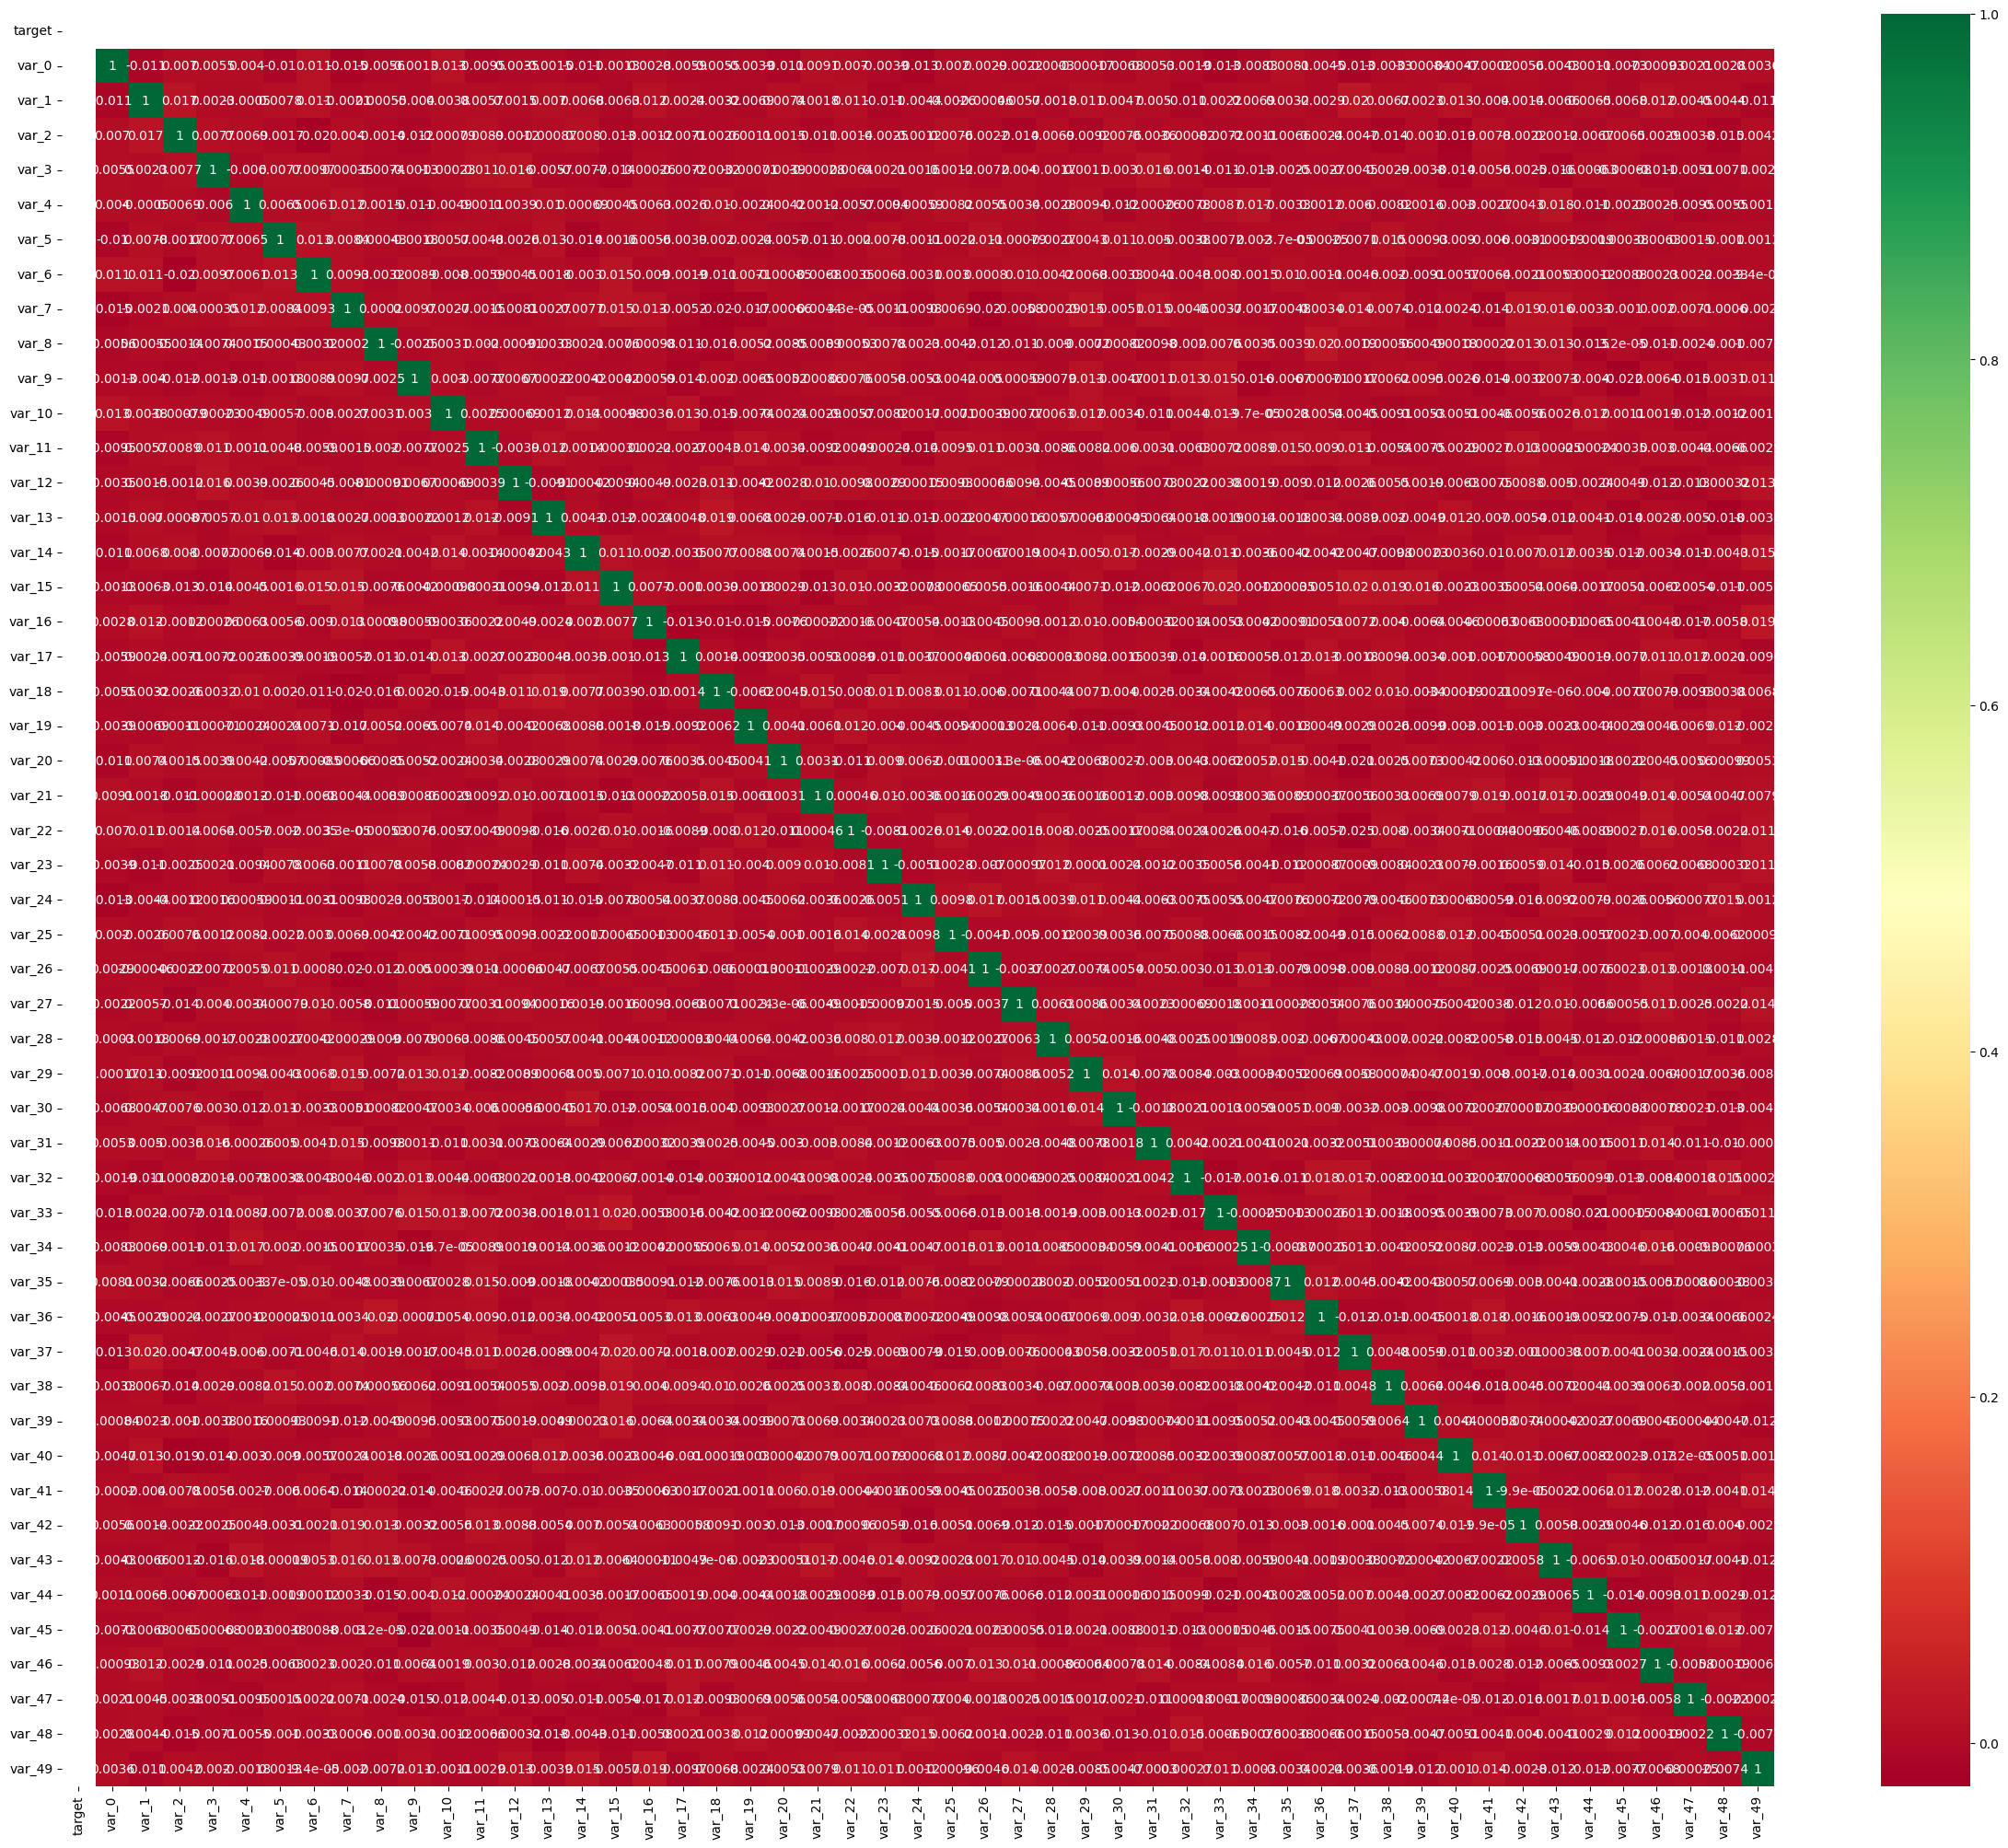

In [47]:
# Correlation Plot
purchased_correlations = purchased.corr()
#column_correlations
plt.figure(figsize=(30,25))
sns.heatmap(purchased_correlations, annot=True, cmap='RdYlGn') ;
plt.savefig('heat-purchased.png')
#, cmap='RdYlGn'

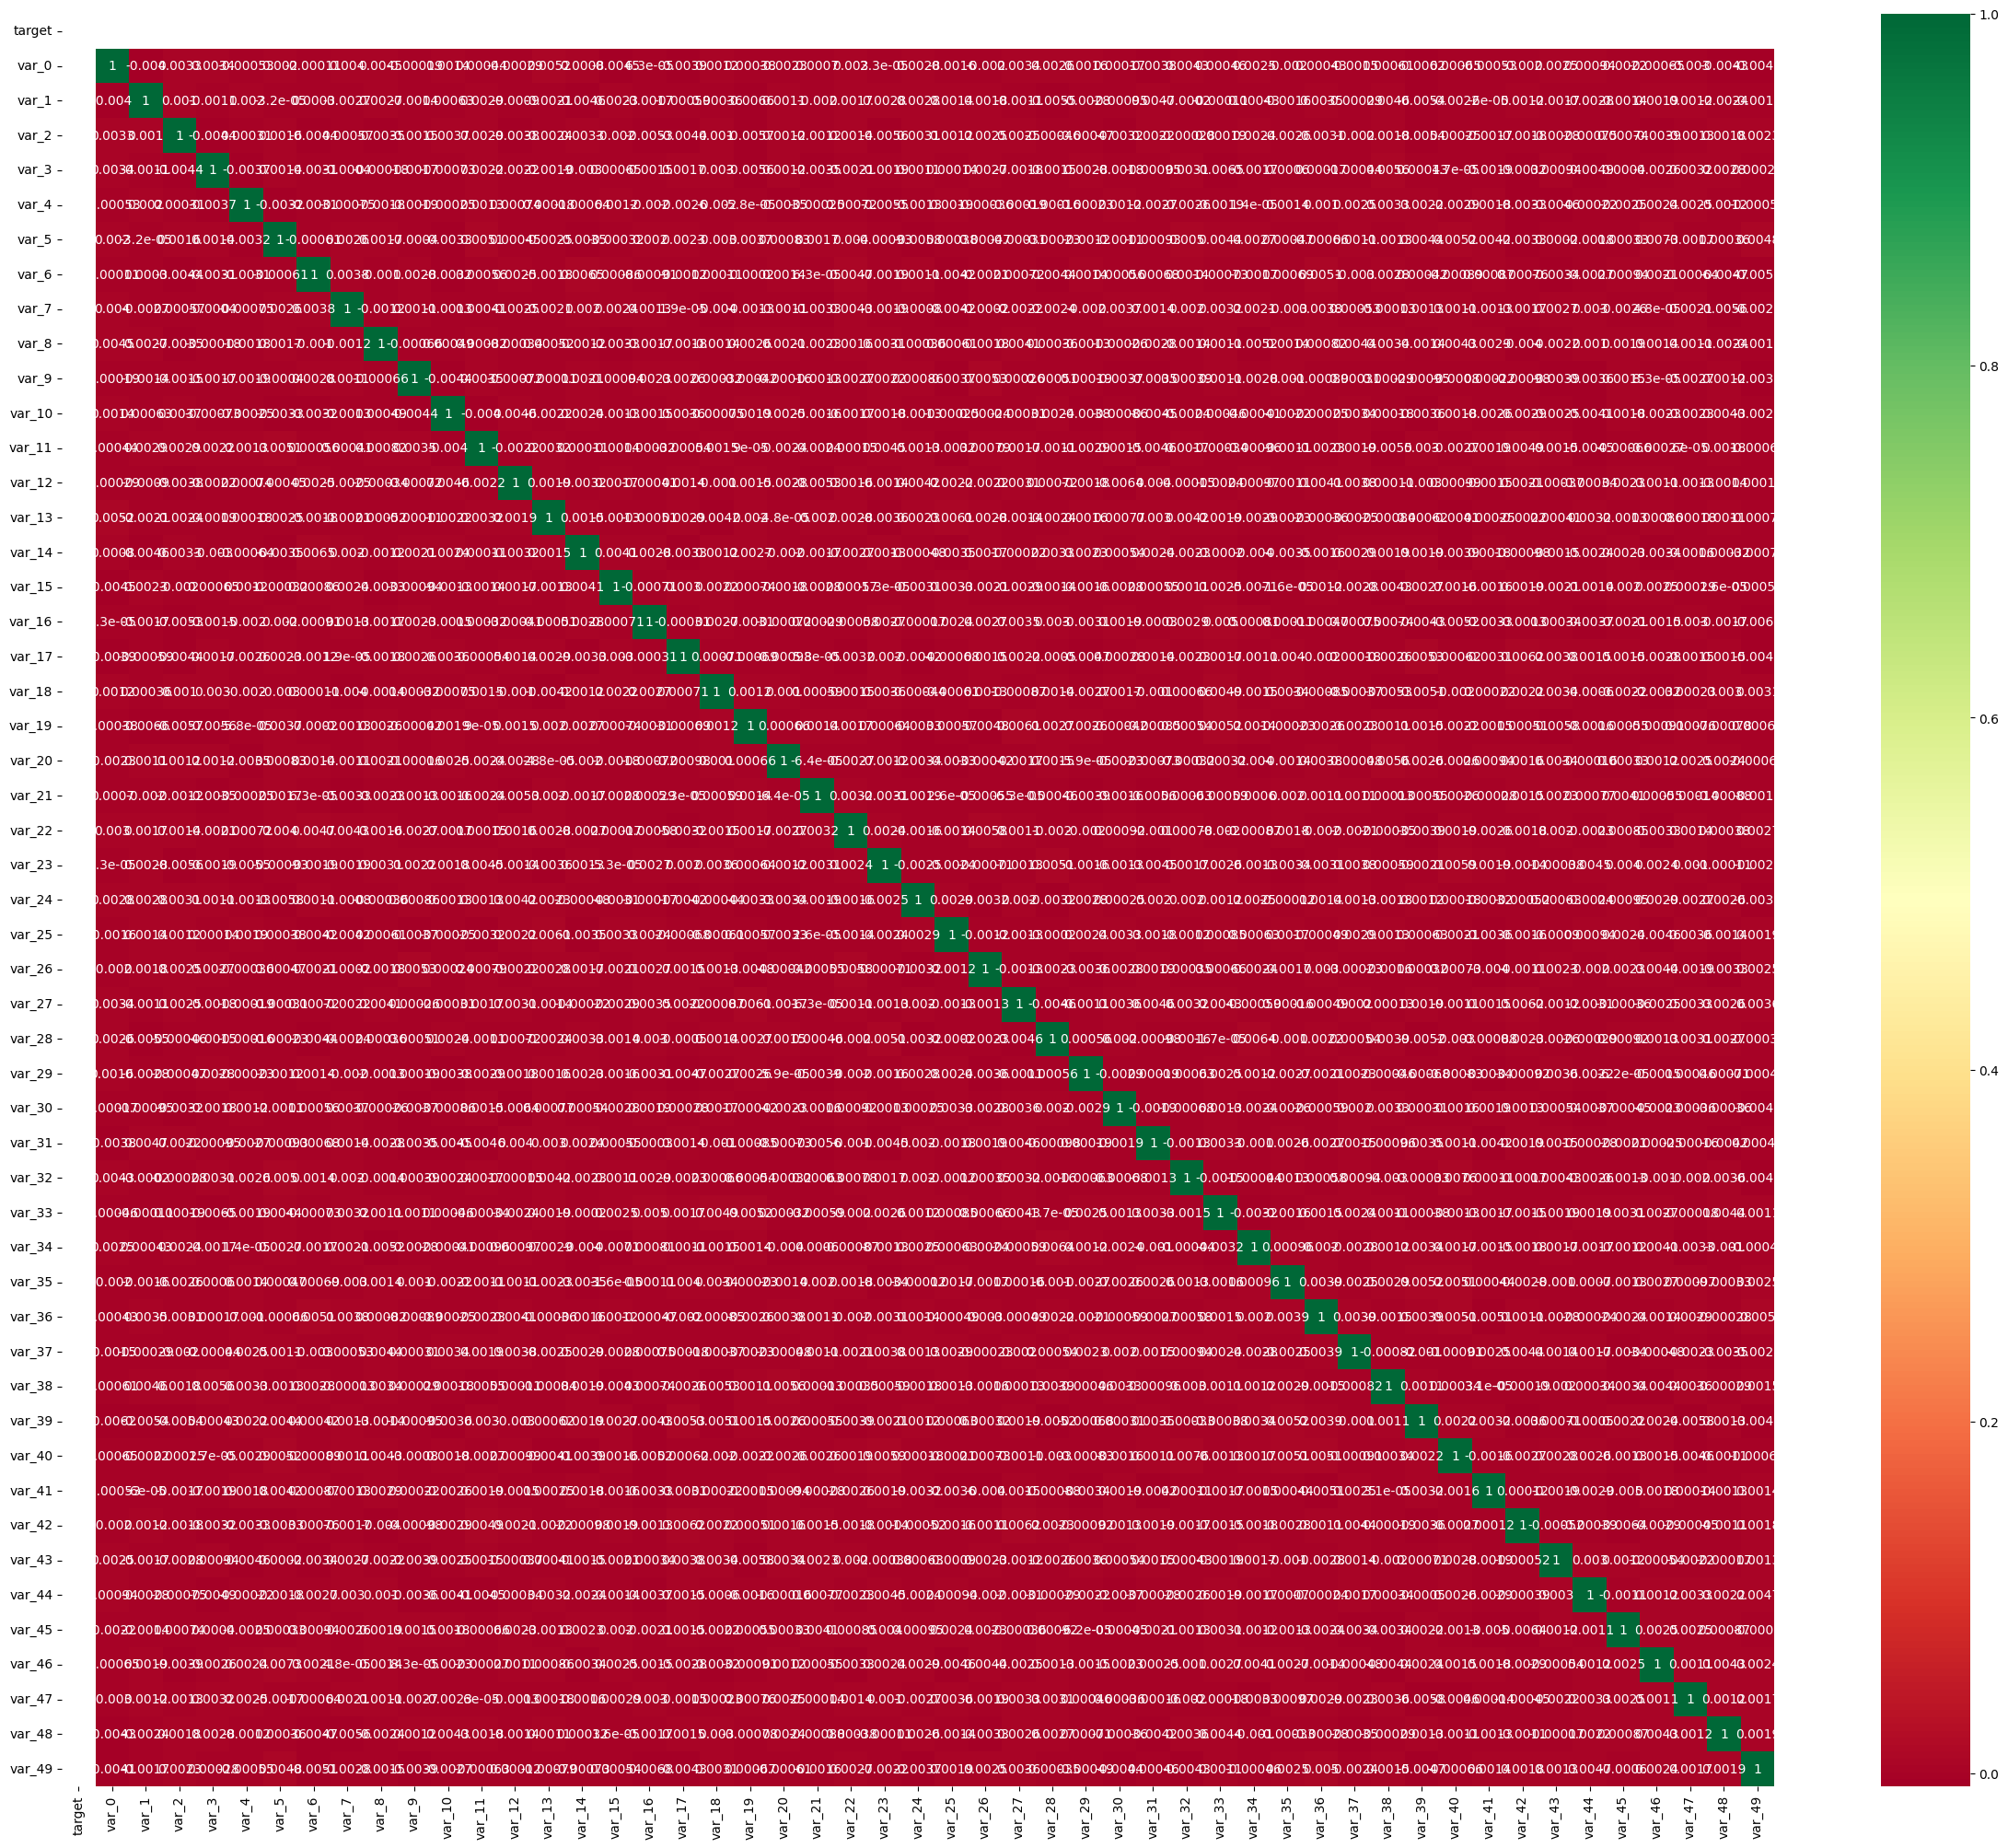

In [48]:
# Correlation Plot
purchased_correlations = not_purchased.corr()
#column_correlations
plt.figure(figsize=(30,25))
sns.heatmap(purchased_correlations, annot=True, cmap='RdYlGn') ;
plt.savefig('heat-nopurch.png')
#, cmap='RdYlGn'

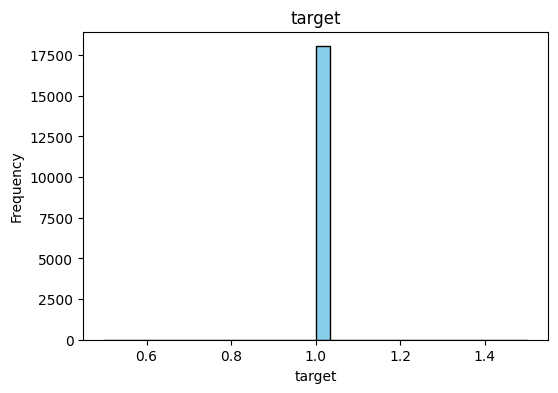

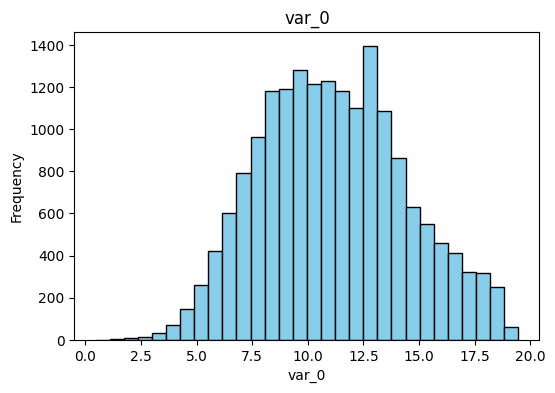

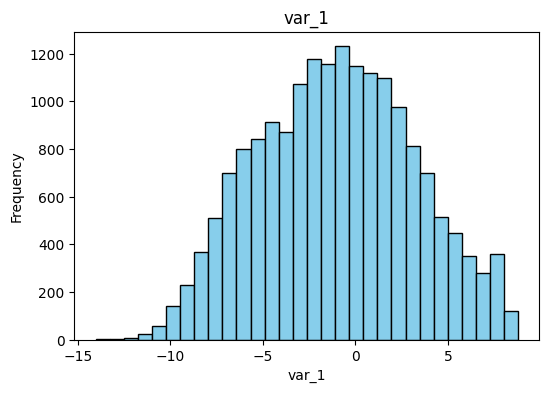

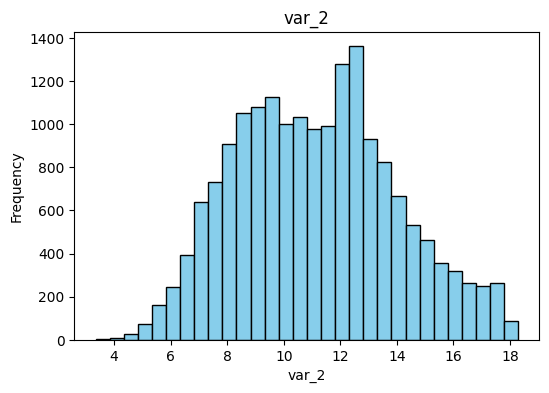

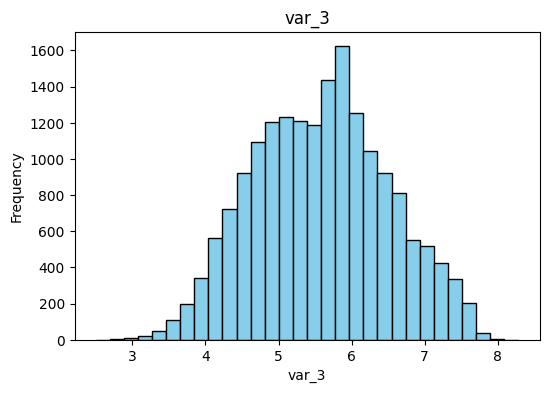

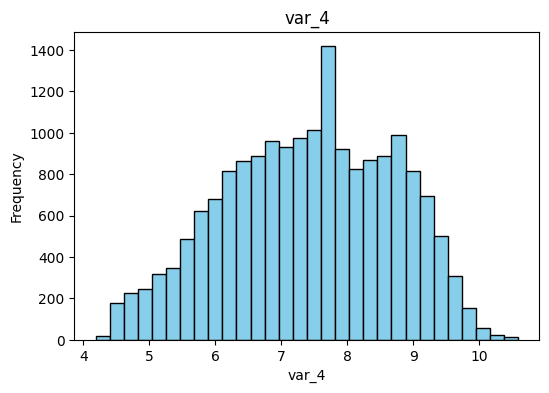

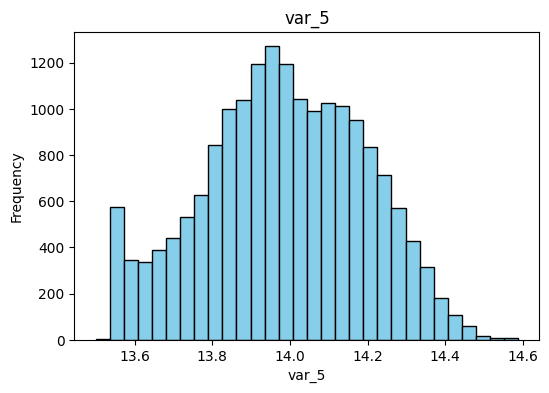

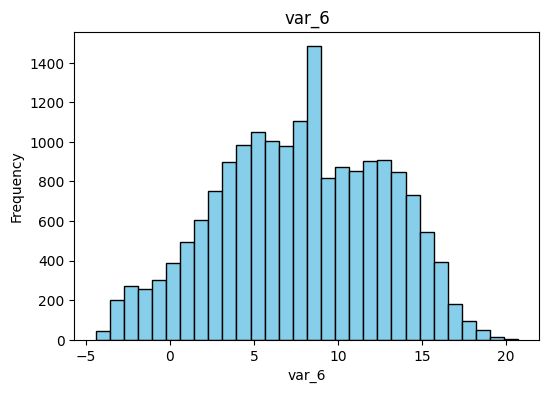

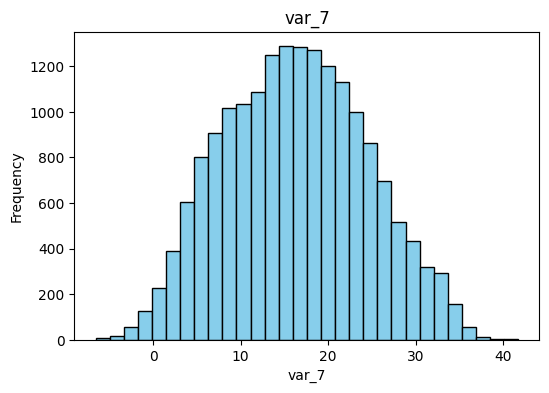

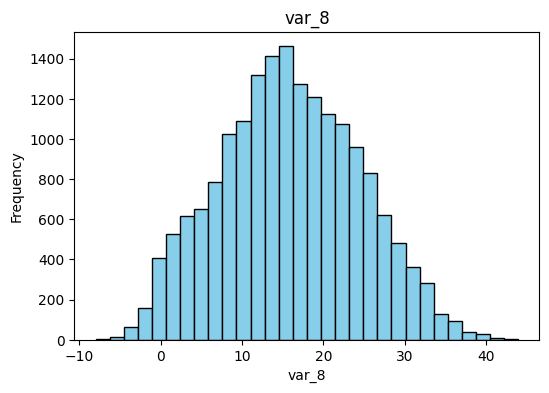

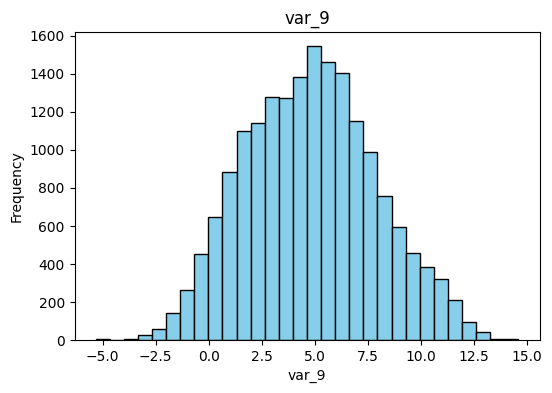

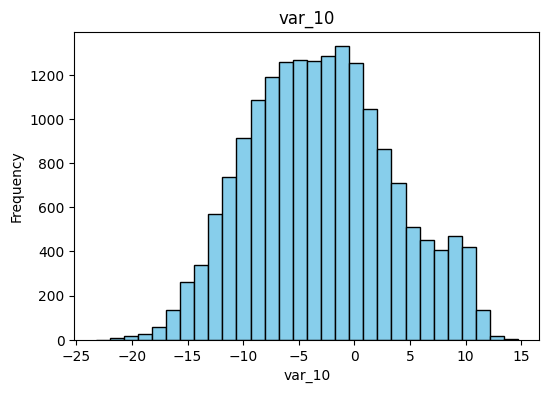

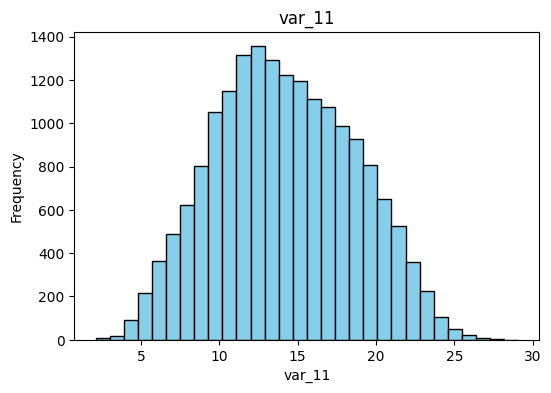

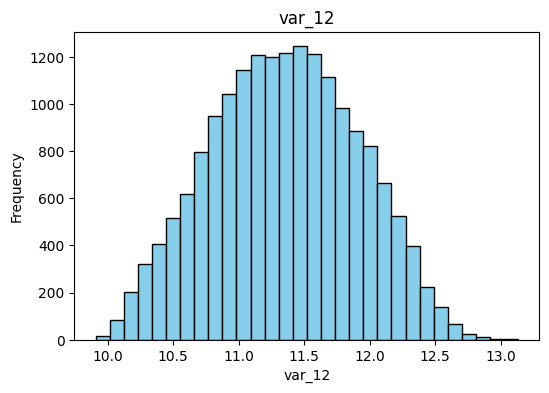

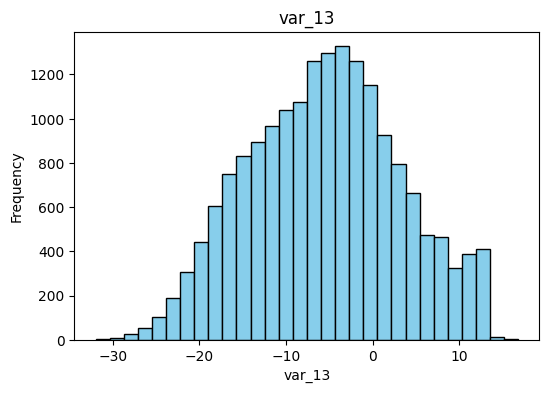

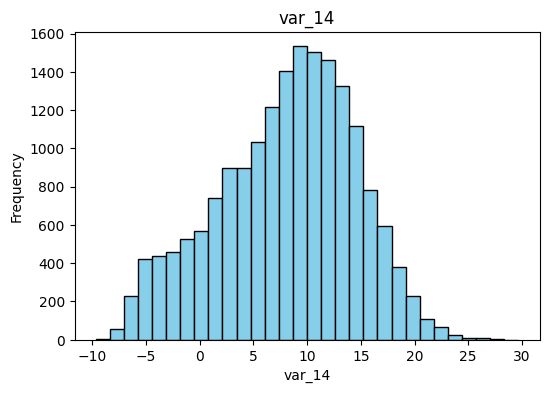

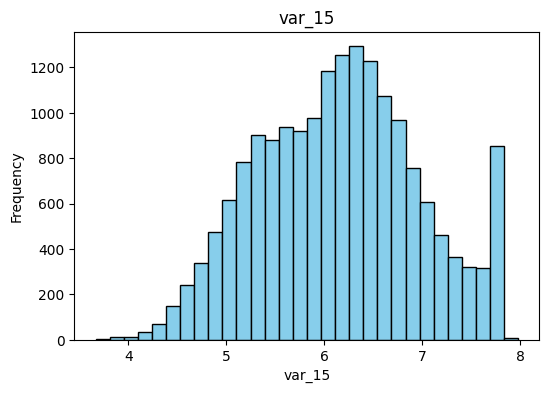

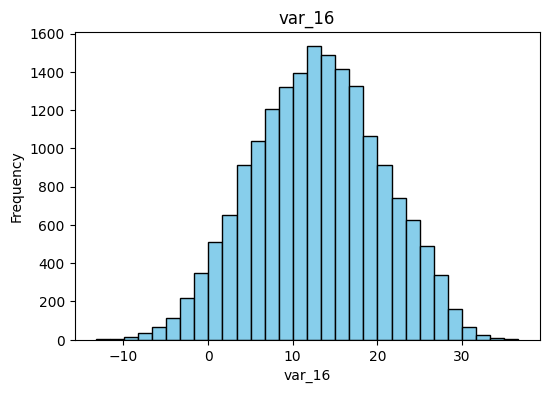

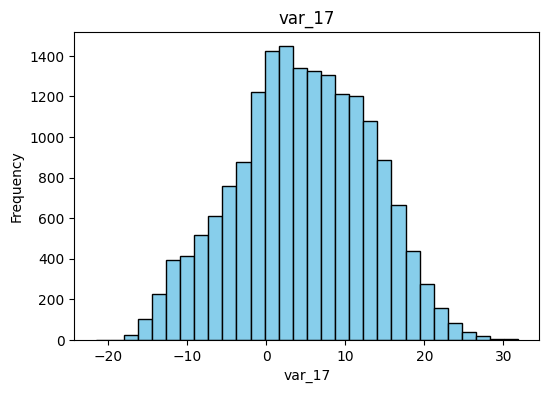

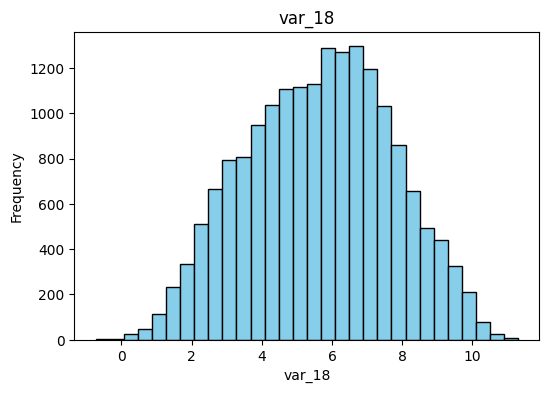

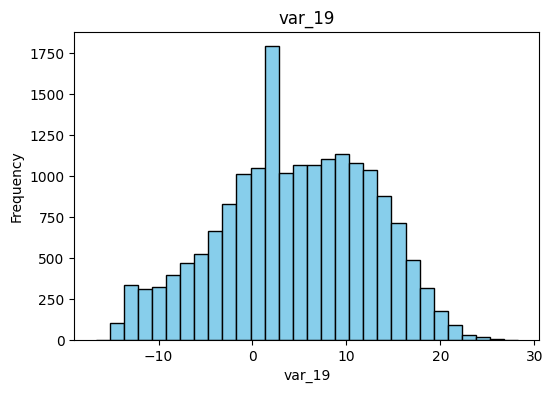

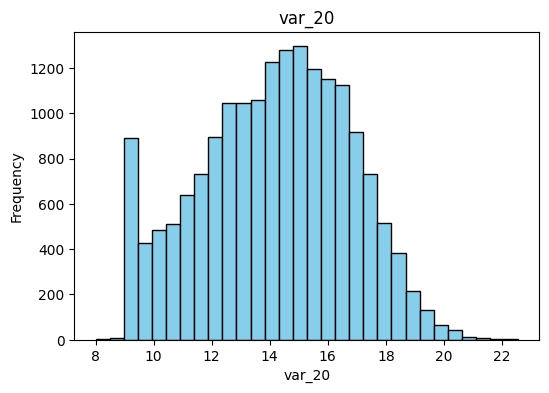

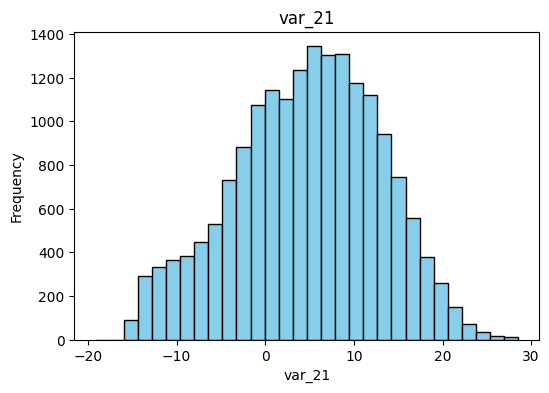

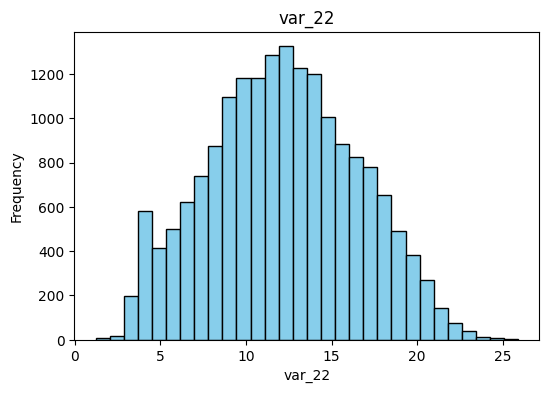

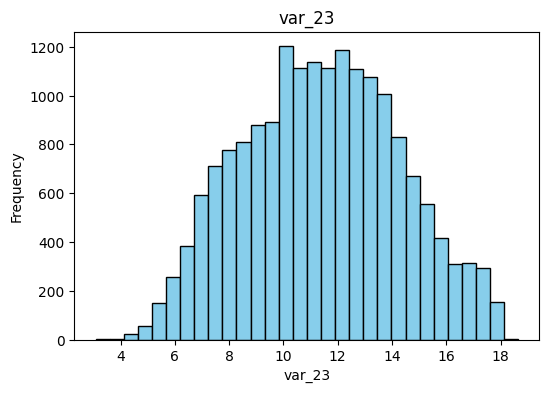

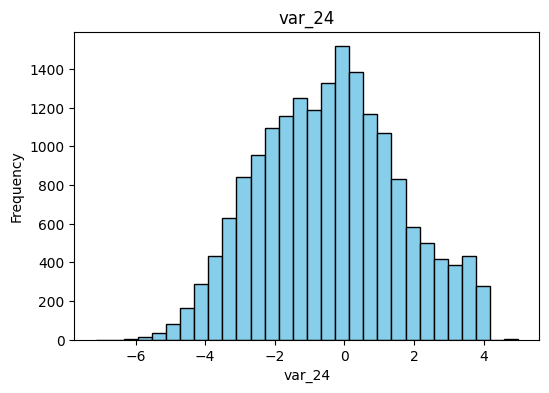

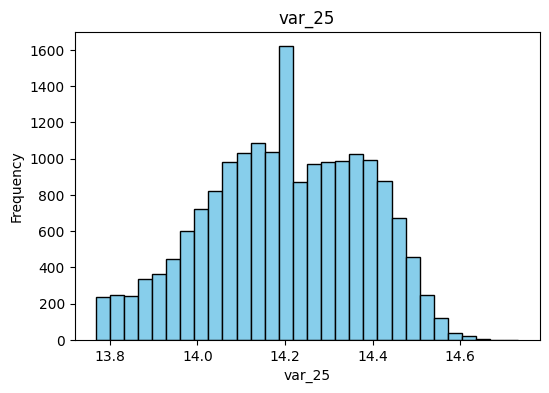

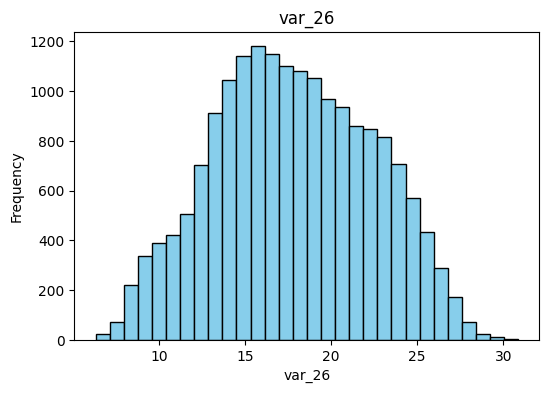

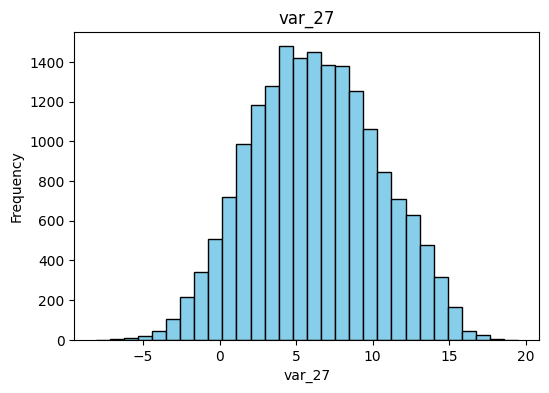

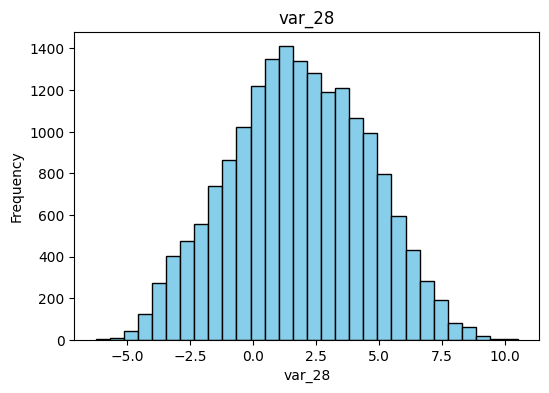

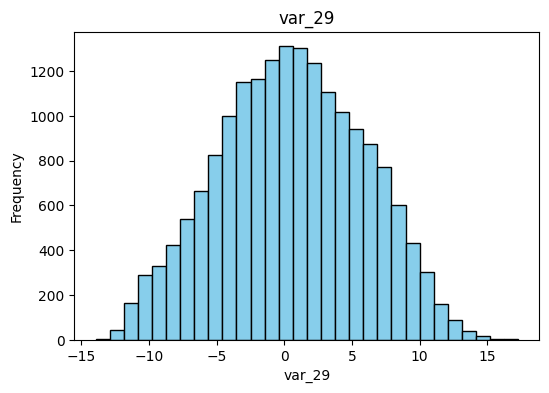

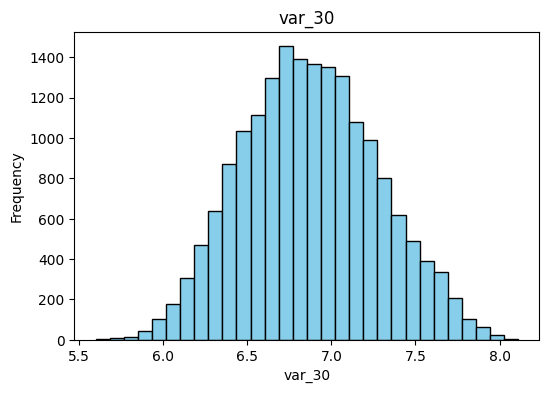

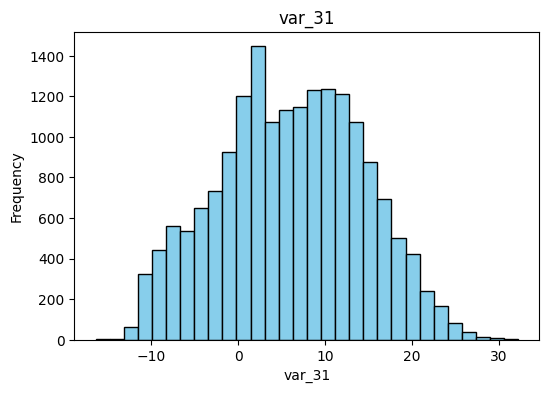

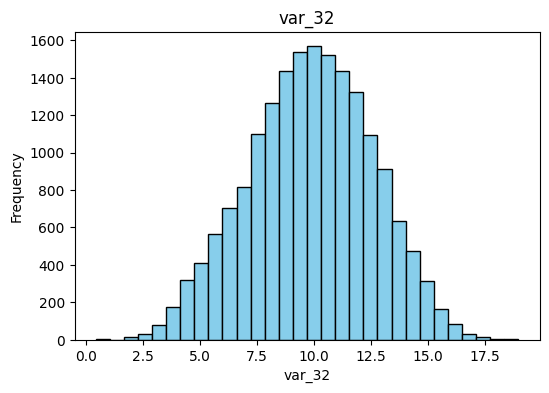

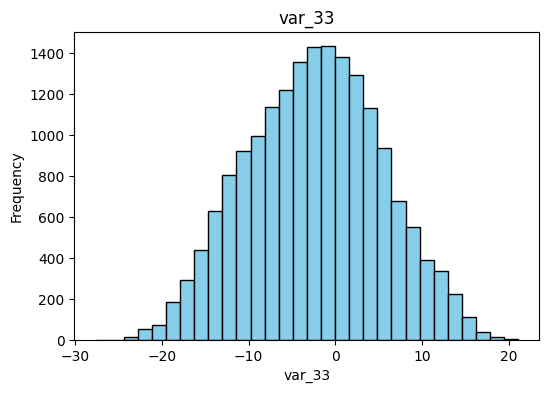

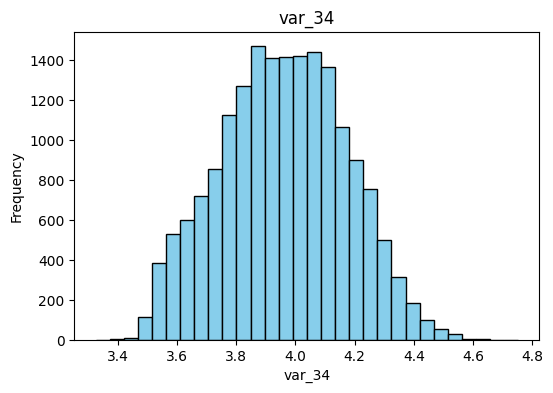

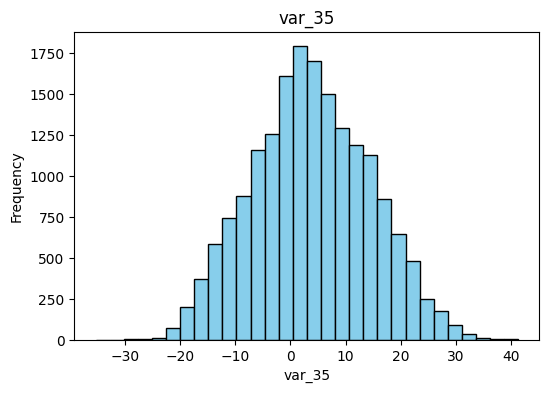

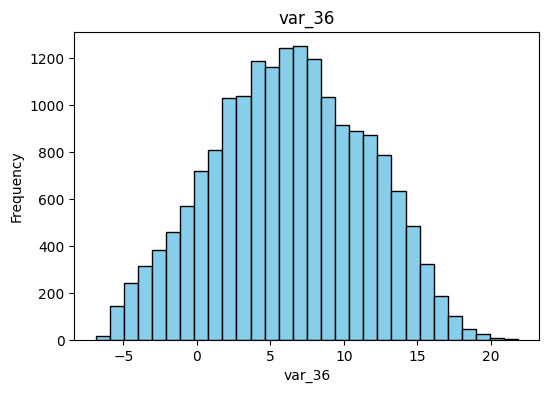

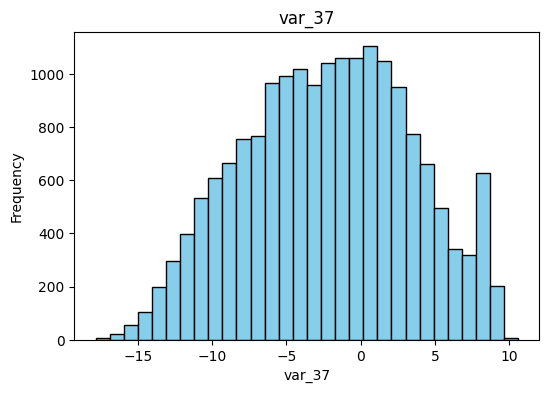

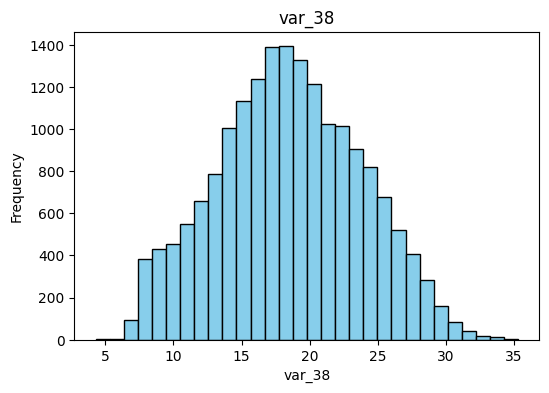

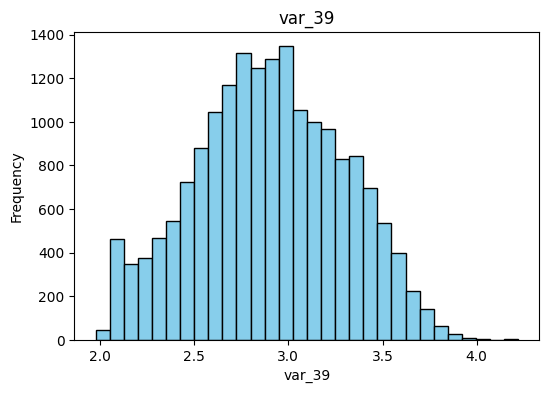

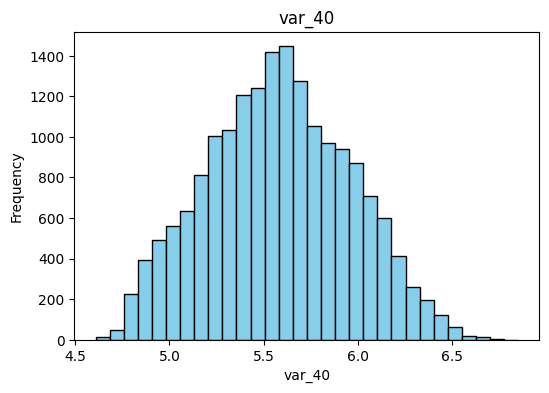

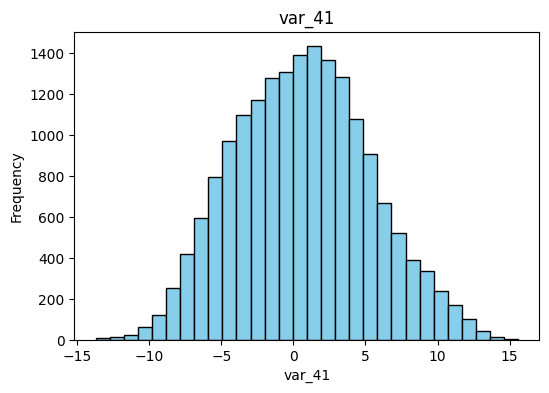

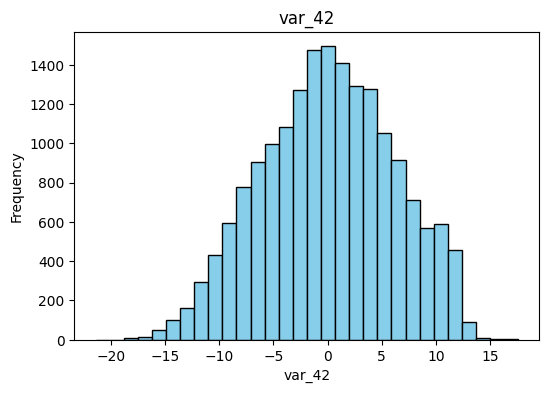

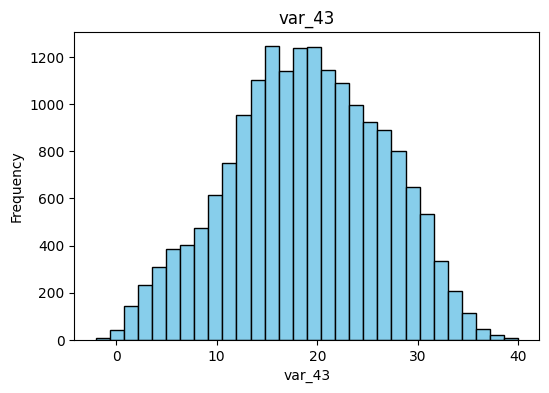

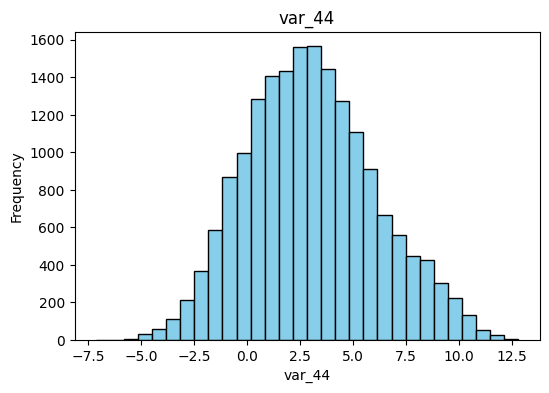

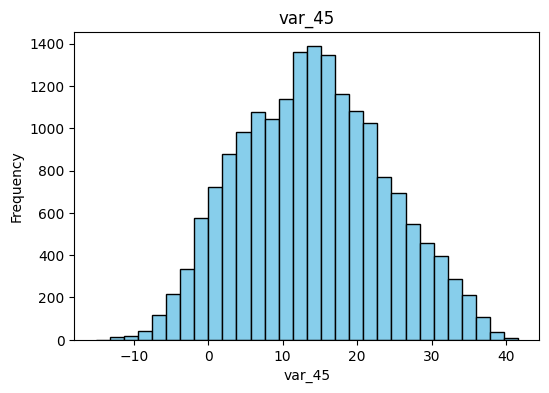

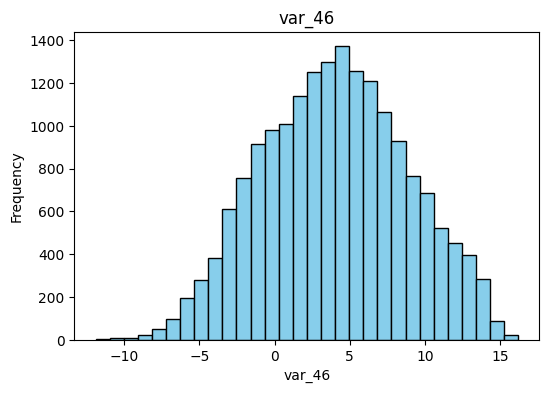

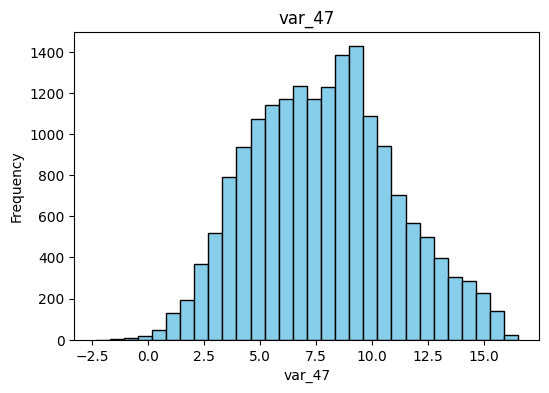

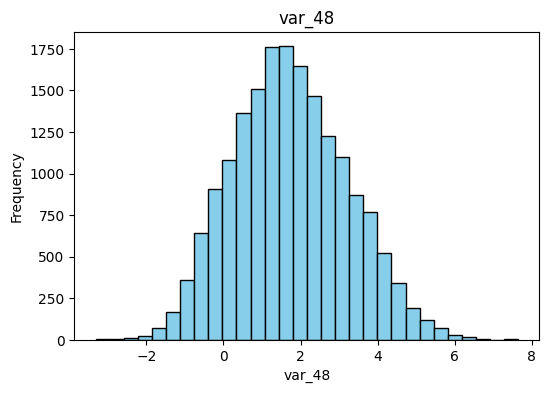

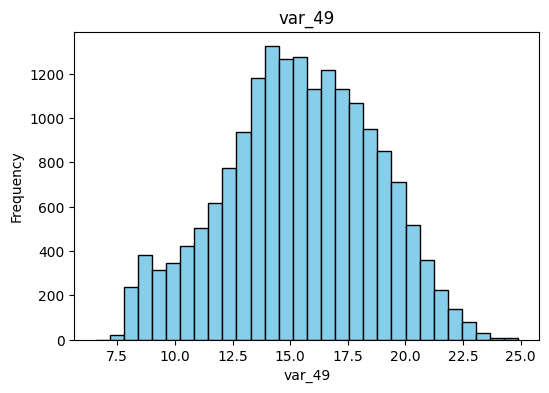

In [49]:
for col in purchased.columns:
    plt.figure(figsize=(6, 4))  # Set figure size
    purchased[col].plot(kind='hist', bins=30, title=col, color='skyblue', edgecolor='black')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.savefig('hist-purch.png')
    plt.show()  # Display each histogram

In [50]:
#var4,5,6,8,11,12,14,17,19,20,21,22,25,26,28,29,31,32,34,35,36,38,39,40,,43,,48,49

In [51]:
tcopy2 = pd.DataFrame(train)

In [52]:
tcopy2.head()

,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,...,var_40,var_41,var_42,var_43,var_44,var_45,var_46,var_47,var_48,var_49
0,0,8.9255,-6.7863,11.9081,5.1187,5.7470,14.0137,0.5745,4.2840,16.2191,...,5.4879,-4.7645,3.1531,18.5618,1.7202,25.8398,4.4354,3.9642,3.1364,12.7803
1,0,11.5006,-4.1473,13.8588,5.6208,8.0851,14.0239,8.4135,7.8000,2.7407,...,5.7999,5.5378,5.5134,30.2645,11.0752,22.5441,7.6421,7.7214,2.5837,18.3560
2,0,8.6093,-2.7457,12.0805,6.9427,5.9525,14.1929,7.3124,4.7011,18.1377,...,5.7690,-7.0927,-5.8234,25.6820,2.4013,23.0866,2.9057,9.7905,1.6704,14.7222
3,0,11.0604,-2.1518,8.9522,5.8428,8.2450,13.8463,11.9704,15.9426,12.5579,...,5.3430,-7.1541,11.7134,14.7483,5.6961,-0.4639,4.4666,4.7433,0.7178,17.9697
4,0,9.8369,-1.4834,12.8746,5.9405,7.6784,13.8481,7.8895,6.5263,18.9608,...,5.5518,1.4493,2.3705,18.4685,5.1743,11.8503,-1.4905,9.5214,-0.1508,17.9974


In [53]:
#keep var4,5,6,8,11,12,14,17,19,20,21,22,25,26,28,29,31,32,34,35,36,38,39,40,,43,,48,49
tcopy2.pop('var_0')
tcopy2.pop('var_1')
tcopy2.pop('var_2')
tcopy2.pop('var_3')
tcopy2.pop('var_7')
tcopy2.pop('var_9')
tcopy2.pop('var_10')
tcopy2.pop('var_13')
tcopy2.pop('var_15')
tcopy2.pop('var_16')
tcopy2.pop('var_18')
tcopy2.pop('var_23')
tcopy2.pop('var_24')
tcopy2.pop('var_27')
tcopy2.pop('var_33')
tcopy2.pop('var_30')
tcopy2.pop('var_37')
tcopy2.pop('var_41')
tcopy2.pop('var_42')
tcopy2.pop('var_44')
tcopy2.pop('var_45')
tcopy2.pop('var_46')
tcopy2.pop('var_47')

,var_47
0,3.9642
1,7.7214
2,9.7905
3,4.7433
4,9.5214
...,...
179995,4.7839
179996,4.2814
179997,3.7701
179998,6.9649


In [54]:
tcopy2.head()

,target,var_4,var_5,var_6,var_8,var_11,var_12,var_14,var_17,var_19,...,var_32,var_34,var_35,var_36,var_38,var_39,var_40,var_43,var_48,var_49
0,0,5.7470,14.0137,0.5745,16.2191,16.8911,11.1920,11.6418,-2.3440,13.6468,...,11.5659,4.0288,17.9244,10.4838,12.6644,2.7004,5.4879,18.5618,3.1364,12.7803
1,0,8.0851,14.0239,8.4135,2.7407,19.3710,11.3702,1.2444,3.2709,2.5462,...,8.9231,4.2578,-4.4223,-0.5687,15.1345,3.2003,5.7999,30.2645,2.5837,18.3560
2,0,5.9525,14.1929,7.3124,18.1377,19.0422,11.0449,4.1006,4.5048,7.4729,...,11.4934,4.0714,-1.2681,-5.1747,20.5092,3.2790,5.7690,25.6820,1.6704,14.7222
3,0,8.2450,13.8463,11.9704,12.5579,6.1796,10.6093,8.0485,11.6875,0.7839,...,10.4994,3.7613,2.3701,17.0336,17.2502,2.5881,5.3430,14.7483,0.7178,17.9697
4,0,7.6784,13.8481,7.8895,18.9608,19.3239,12.4057,6.9087,1.0273,2.9598,...,11.5670,3.7574,9.9110,4.7022,21.2607,3.2304,5.5518,18.4685,-0.1508,17.9974


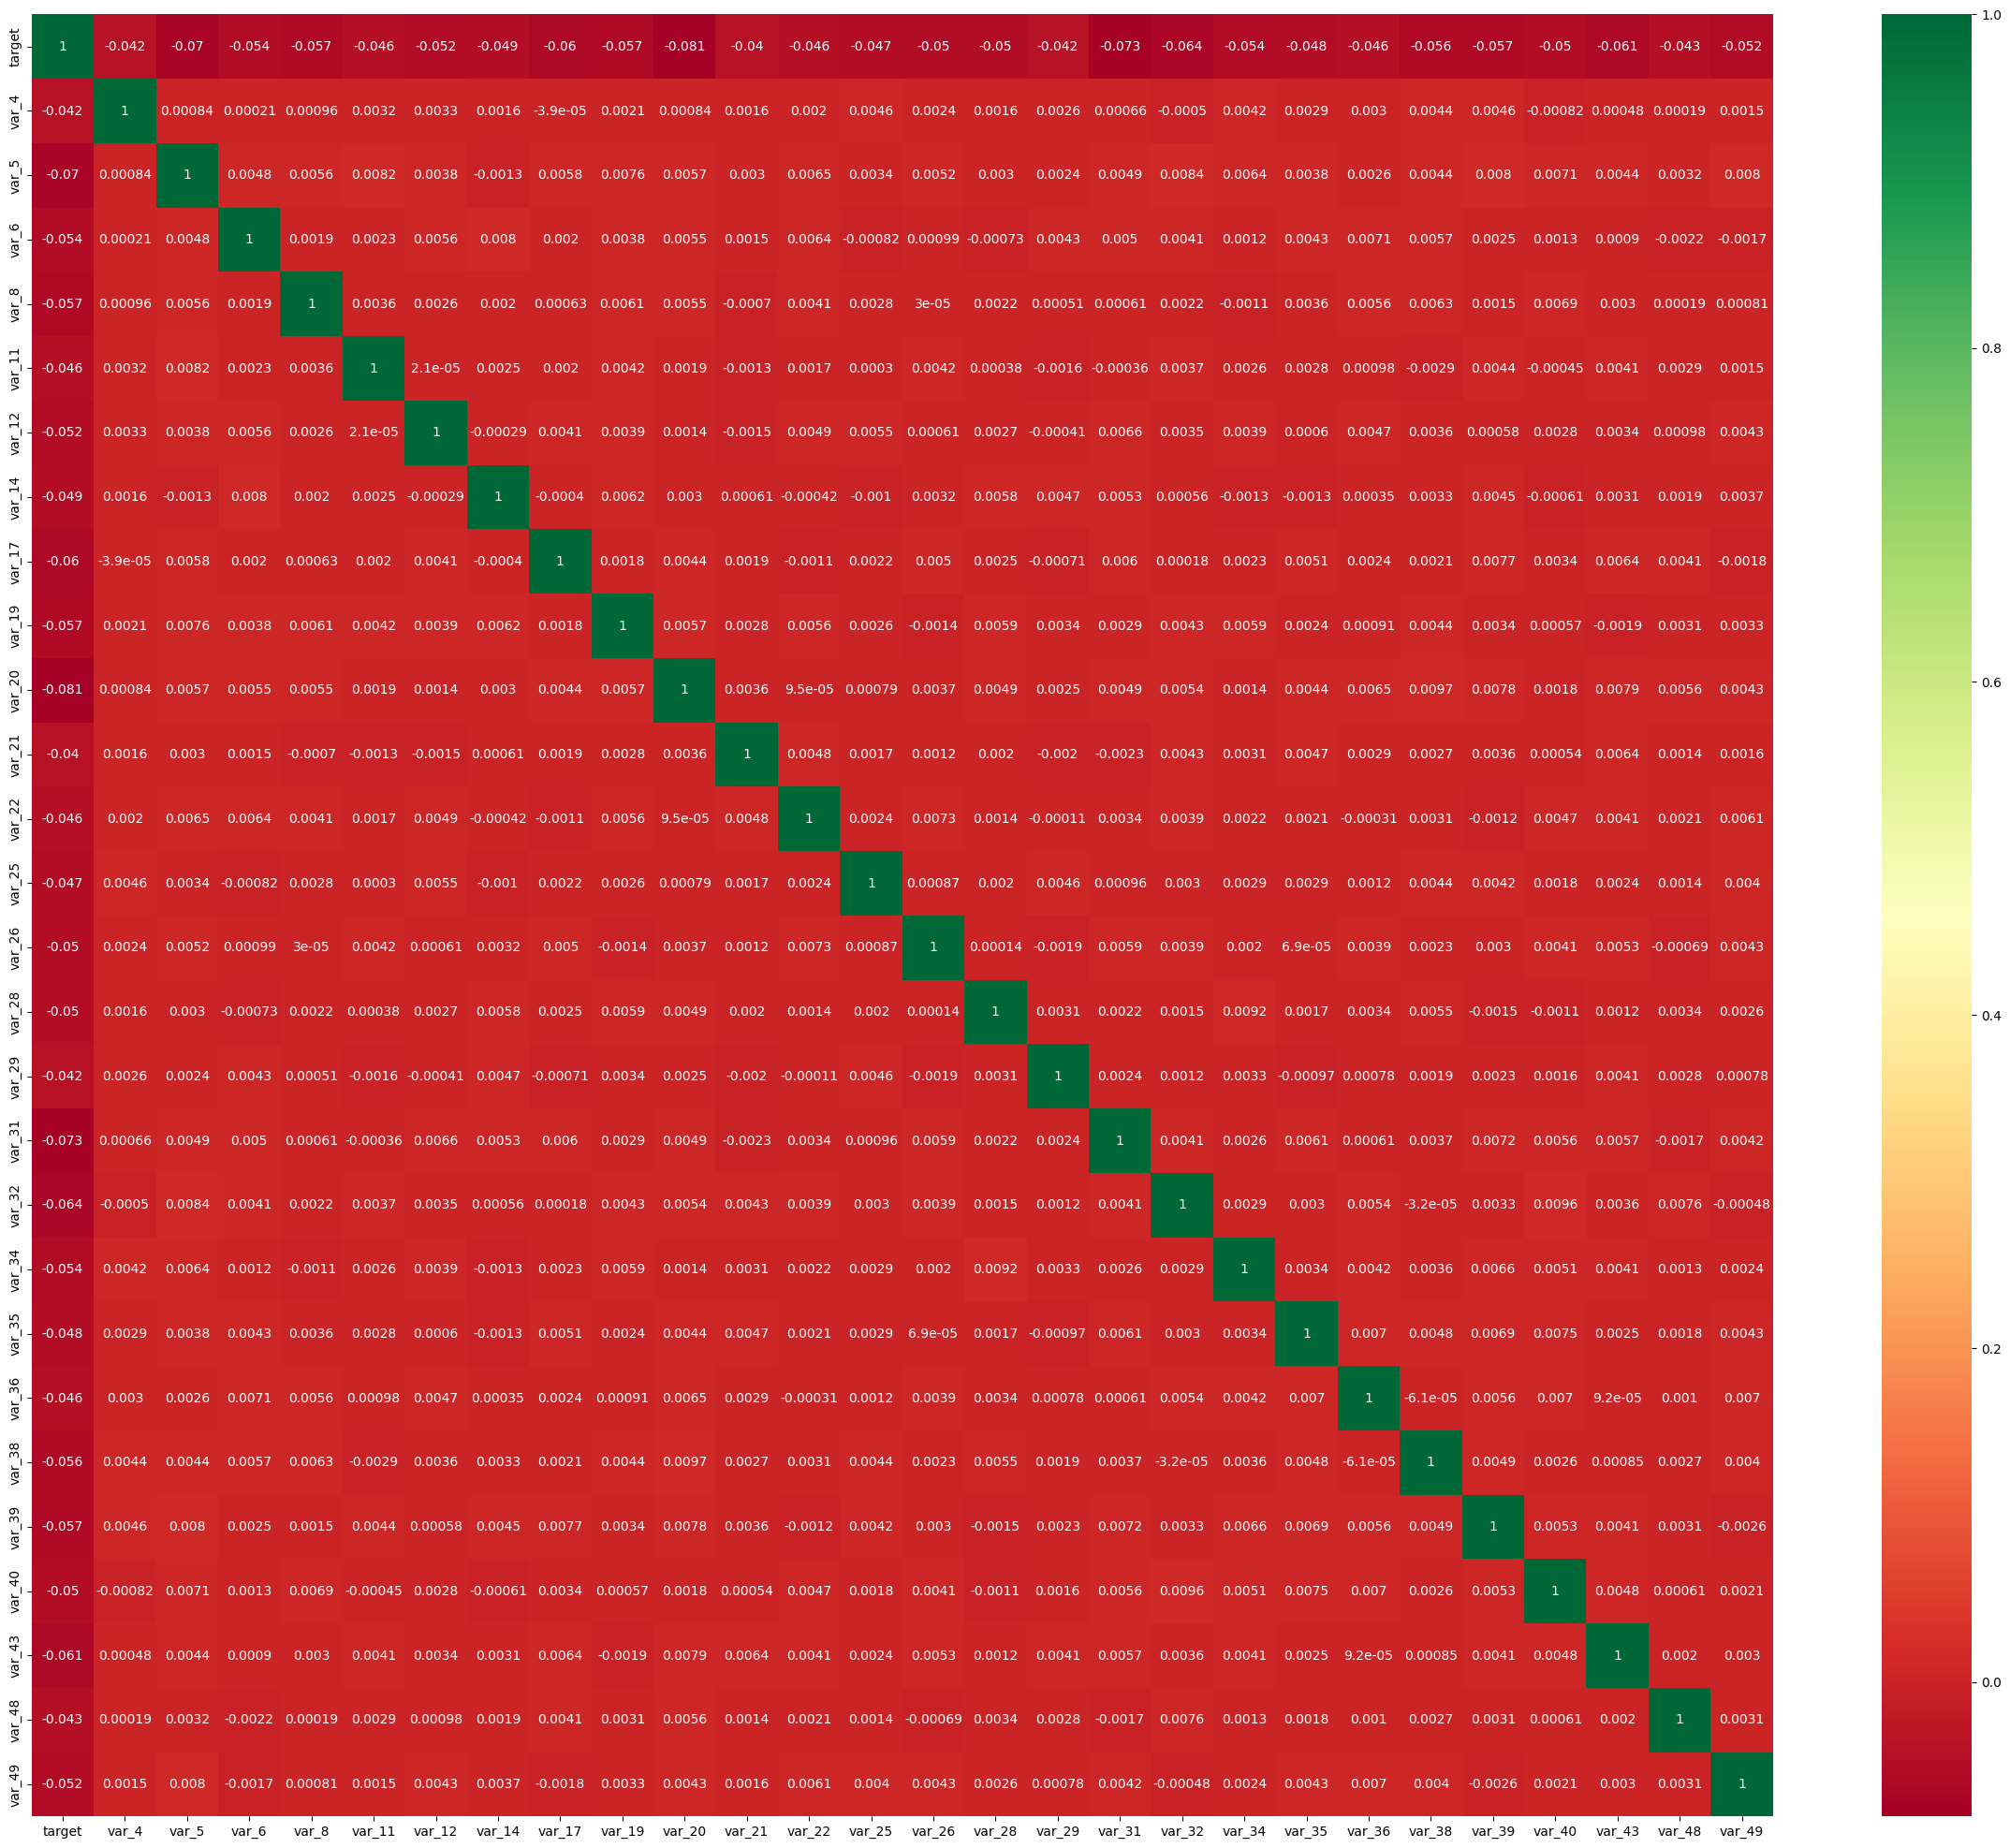

In [55]:
import seaborn as sns
# Correlation Plot
tcopy2_correlations = tcopy2.corr()
#column_correlations
plt.figure(figsize=(30,25))
sns.heatmap(tcopy2_correlations, annot=True, cmap='RdYlGn') ;
plt.savefig('heat-subset.png')
#, cmap='RdYlGn'

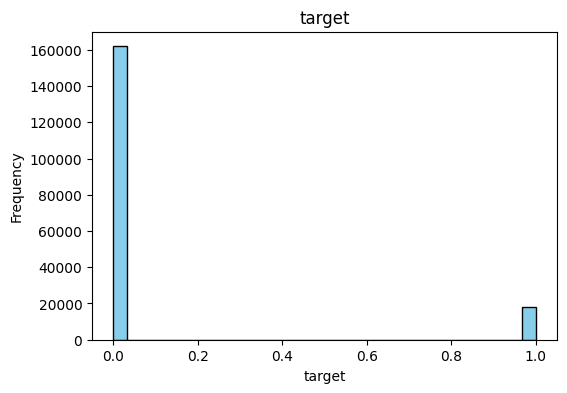

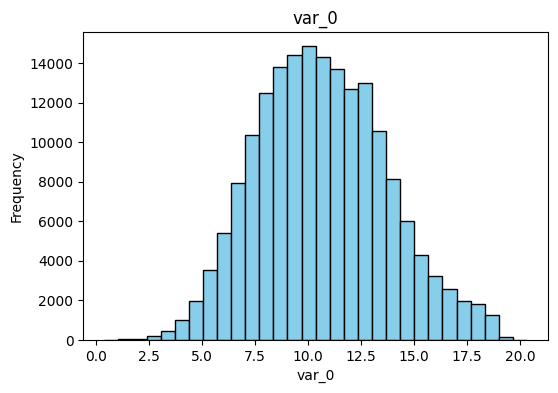

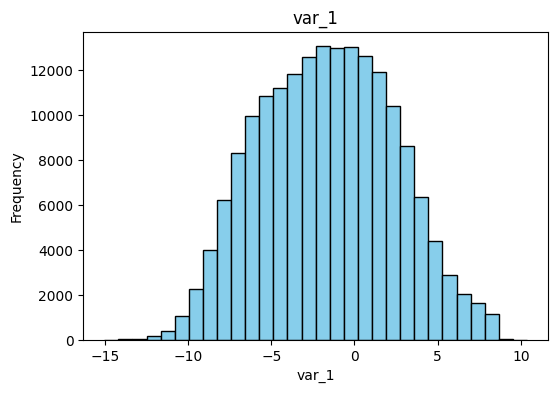

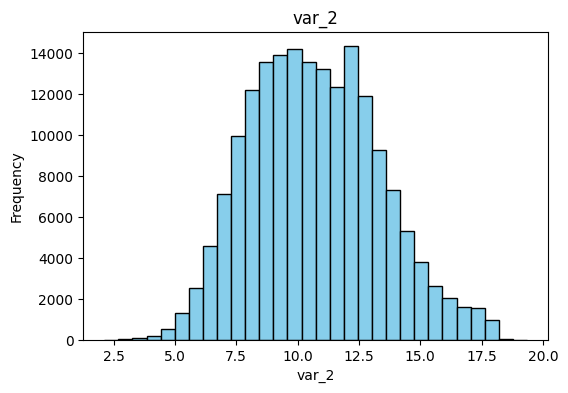

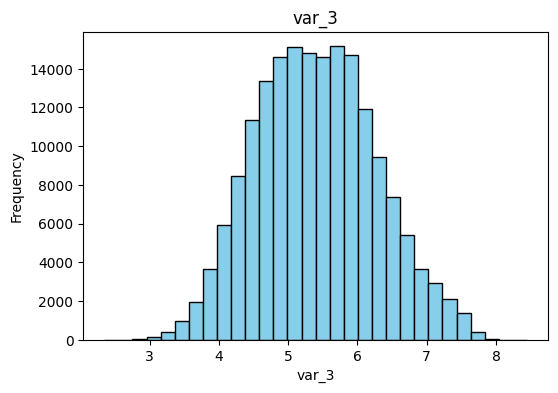

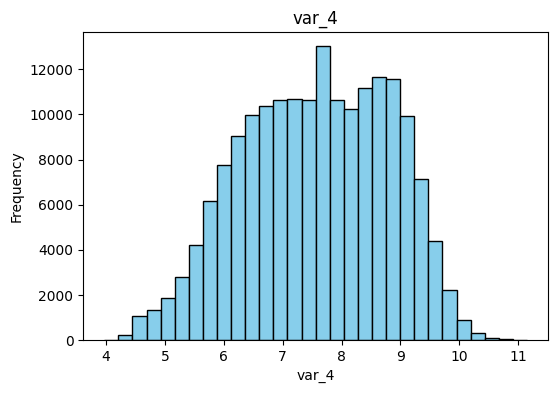

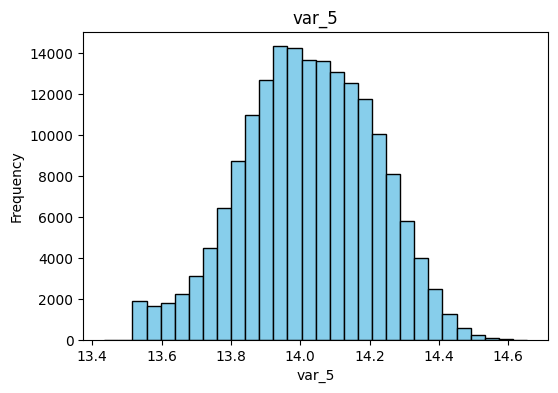

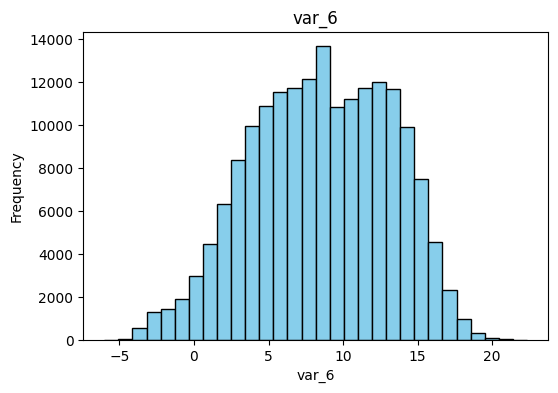

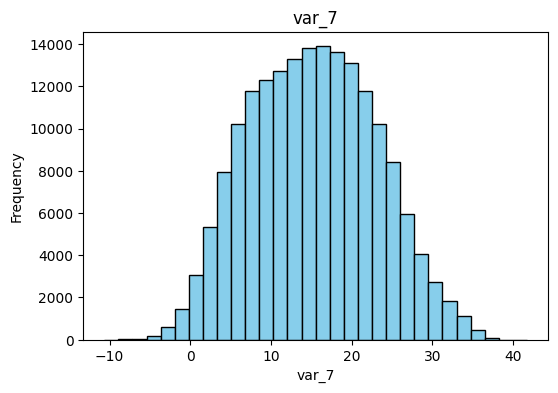

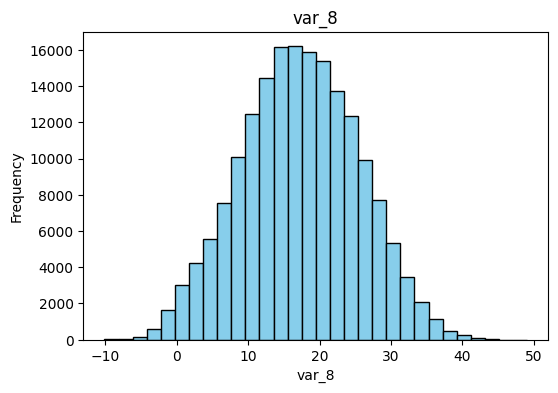

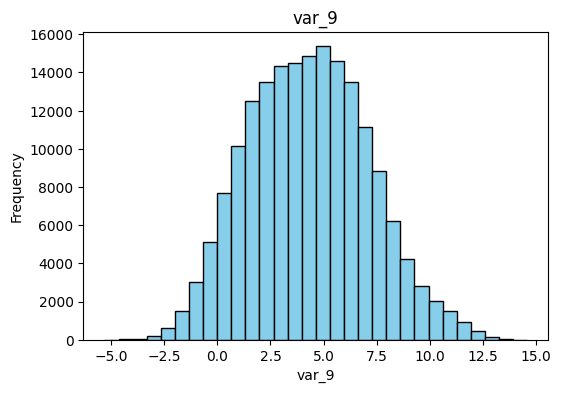

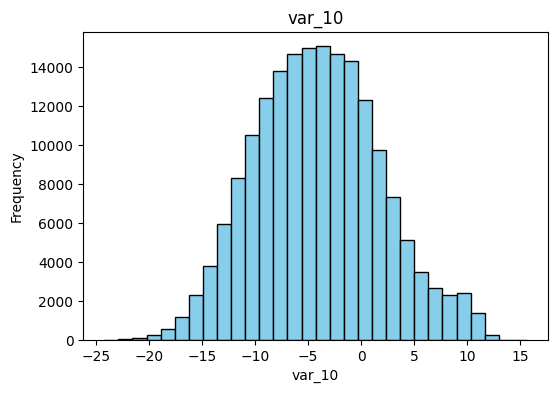

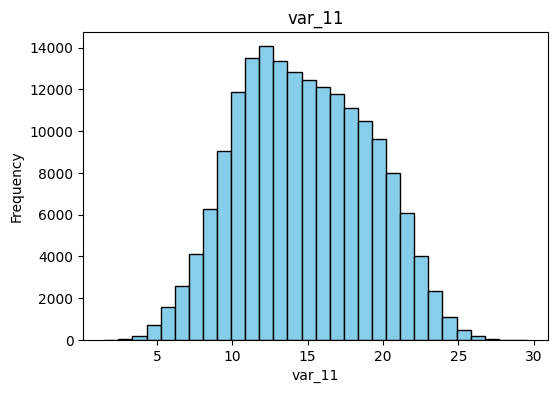

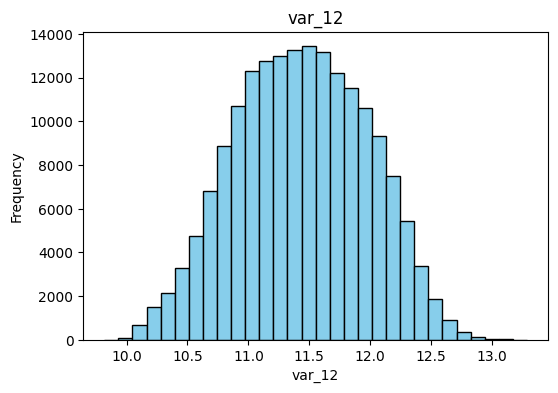

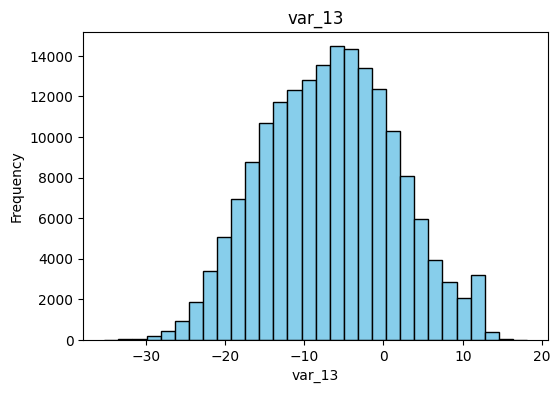

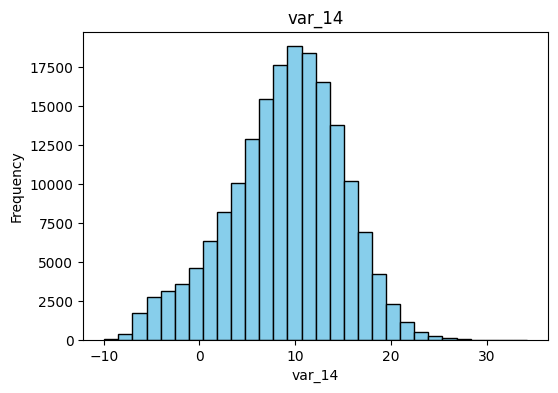

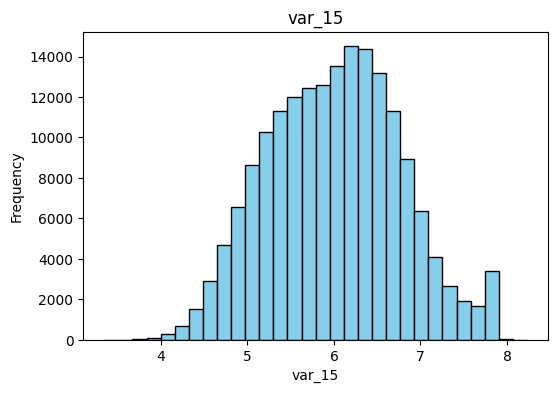

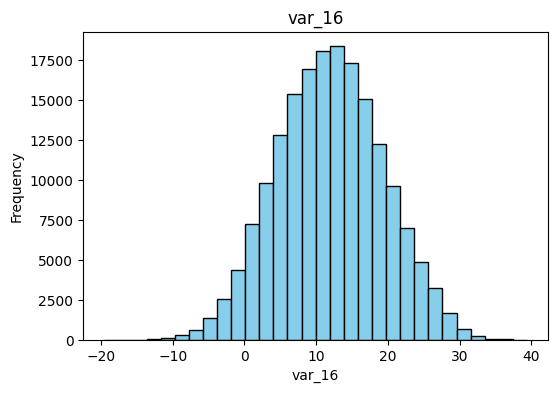

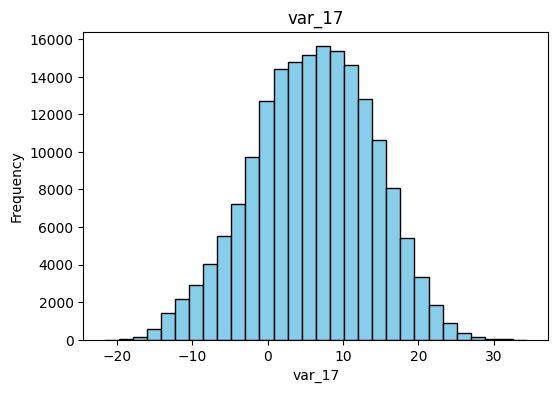

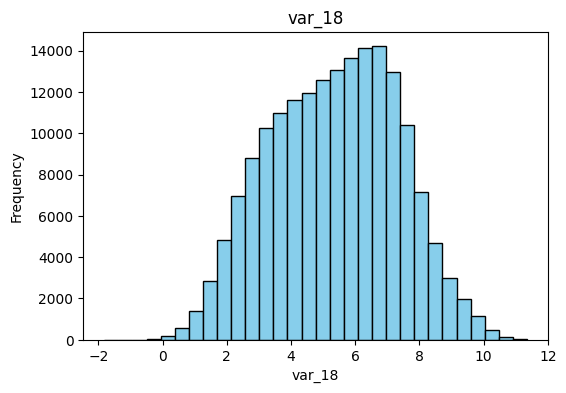

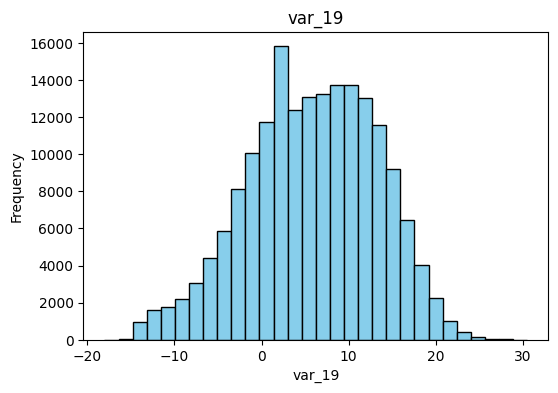

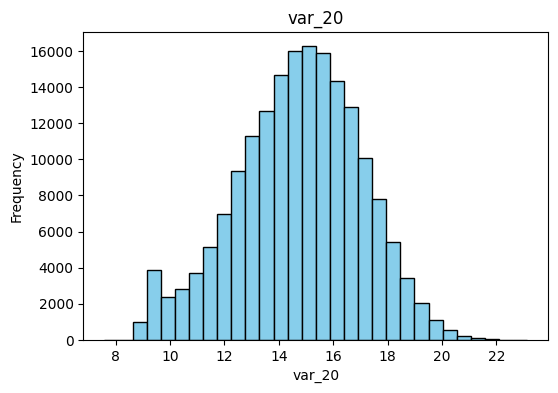

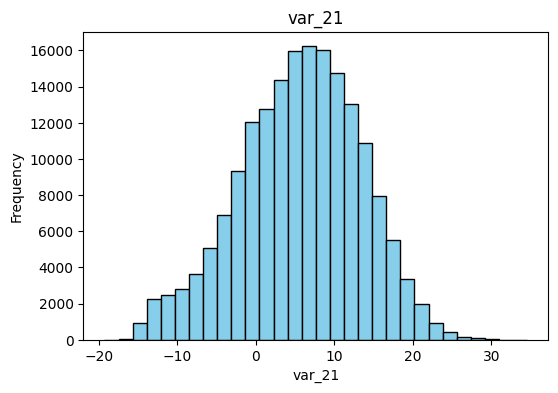

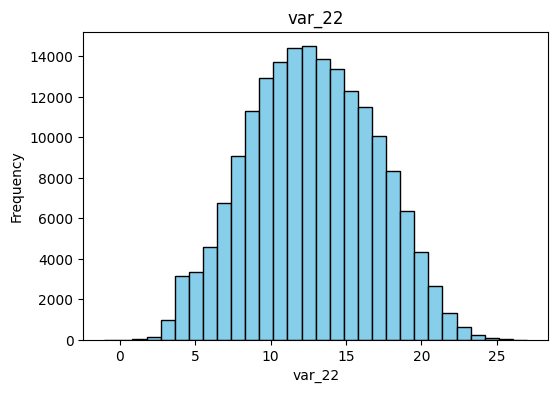

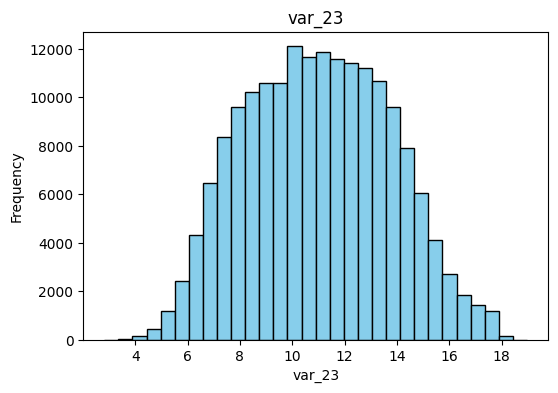

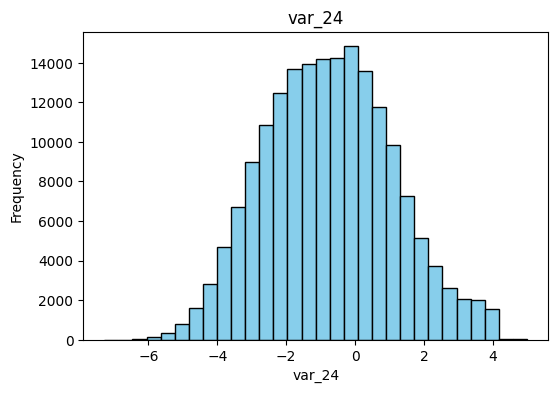

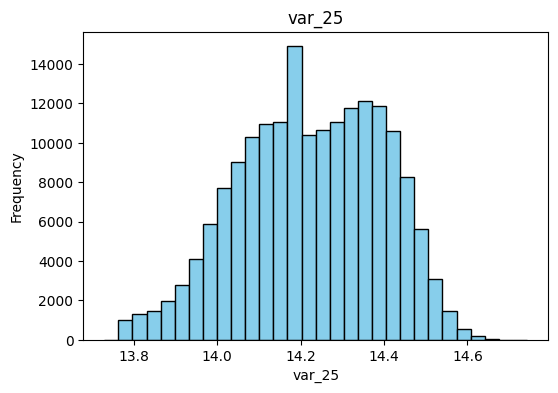

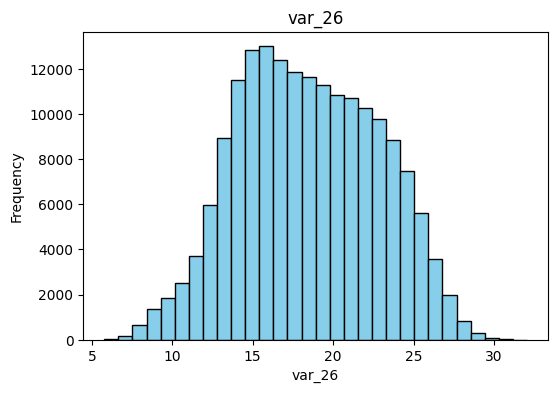

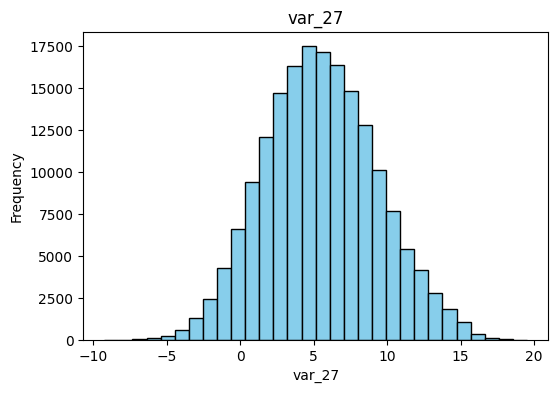

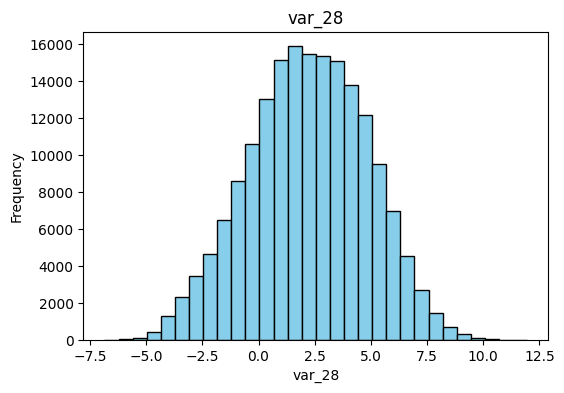

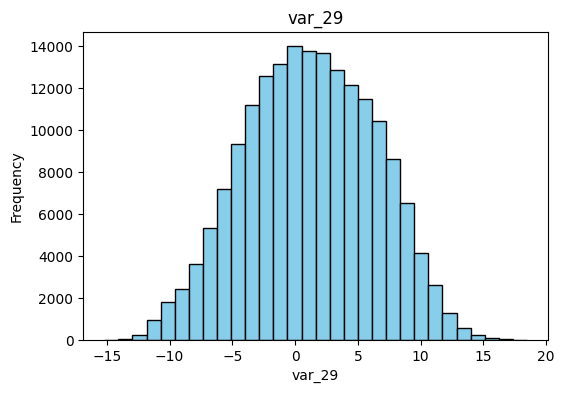

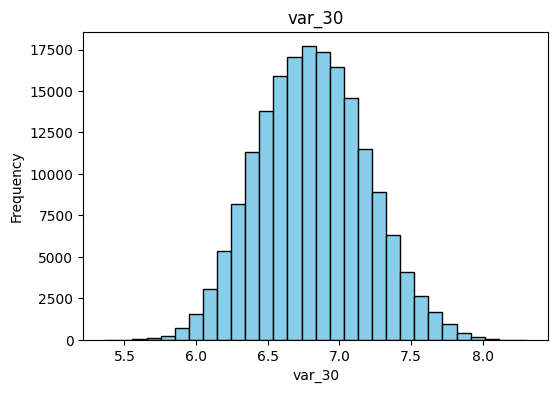

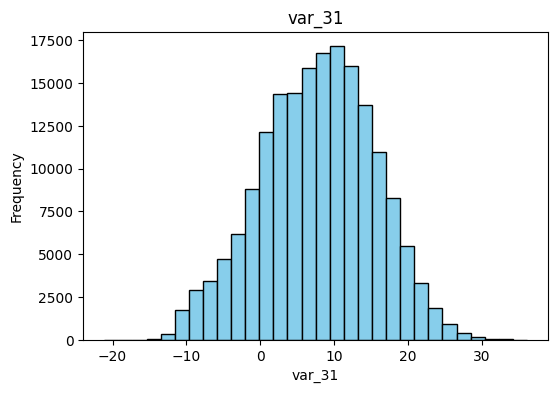

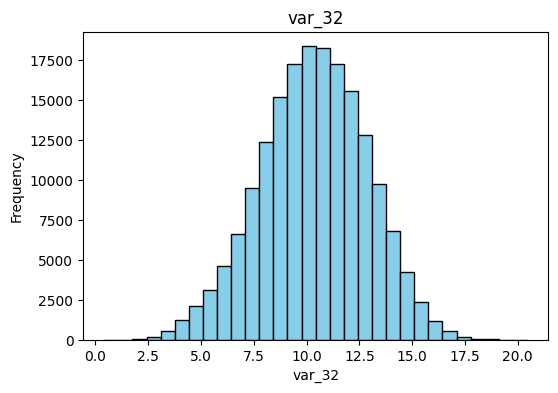

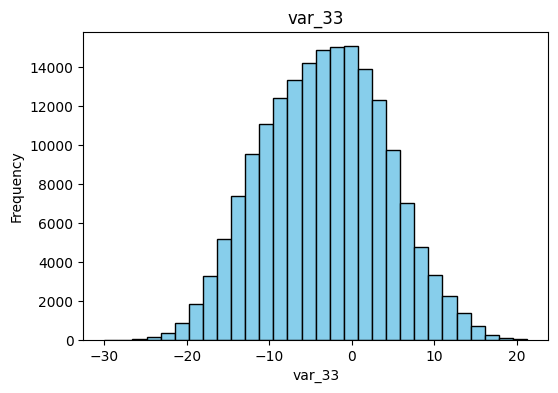

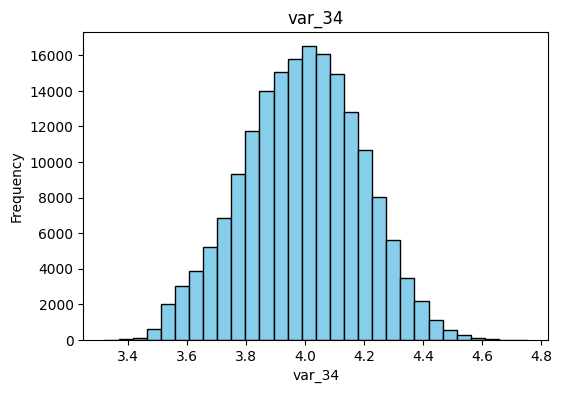

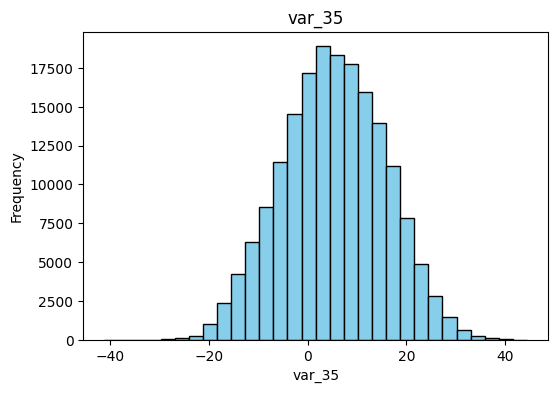

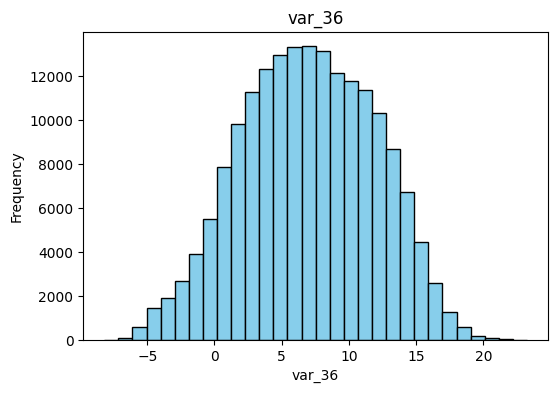

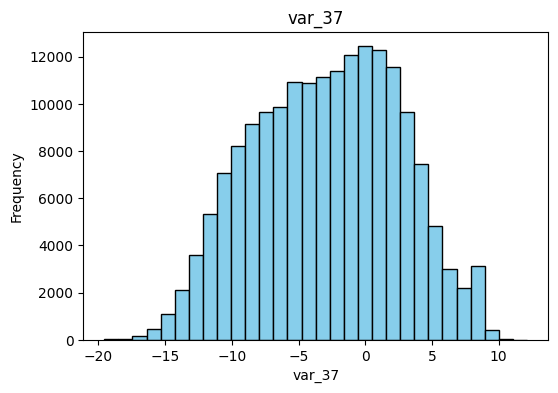

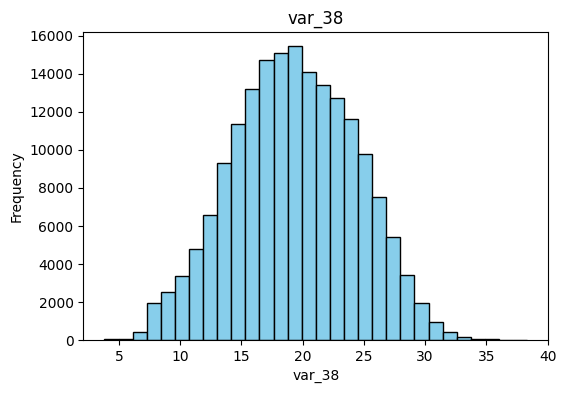

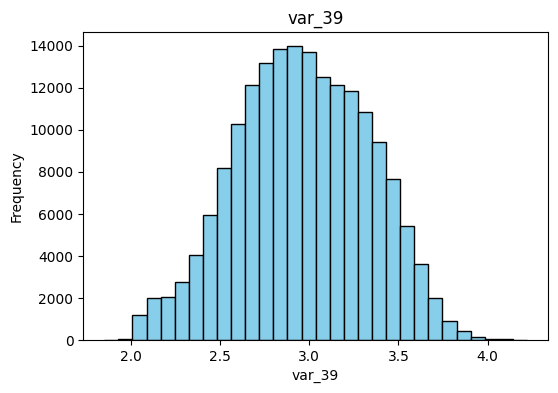

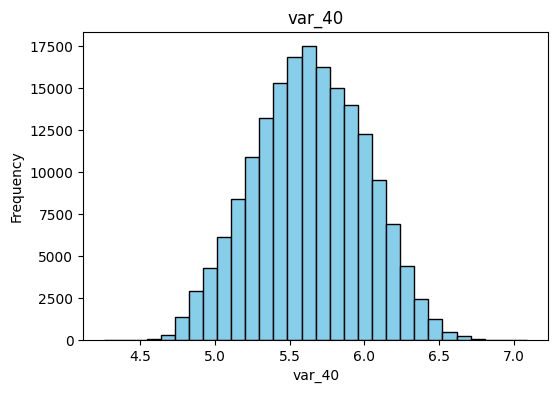

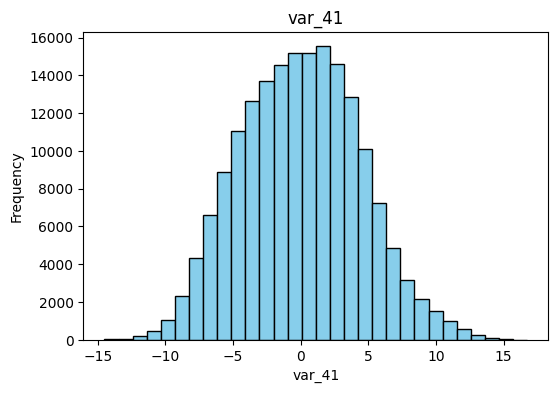

In [ ]:
for col in train.columns:
    plt.figure(figsize=(6, 4))  # Set figure size
    train[col].plot(kind='hist', bins=30, title=col, color='skyblue', edgecolor='black')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.savefig('hist-all.png')
    plt.show()  # Display each histogram


In [ ]:
#correlated_purchased = abs(purchased).sort_values(ascending=False)
#correlated_purchased

Nothing helpful found in data. Use titanic to be most helpful and project 1 - to do list and project questions

## Data Processing

10. Create two data frames: one with all the predictor columns (everything except for Unnamed: 0, ID_code and target) and one with just the target. Make sure they are copies and not slices.

1. Define a Gaussian Naïve Bayes model using Sklearn.

1. Divide the two data frames you created in step #10 into training and testing subsets.

1. Train the model using the training subset of the dataset.

1. Test the model using the testing subset of the dataset. Calculate and report the accuracy.

1. Perform a cross-validation loop to calculate the accuracy of your model. Report that accuracy. How does it compare to the accuracy you calculated in #14?

1. Plot a histogram of the accuracy scores you generated in your cross-validation loop. What do you notice about the distribution of accuracy scores?

1.  Present the confusion matrix and the results of your Classification Report (sklearn.metrics.classification_report). What do you notice?

1. The training data is very skewed towards non-successful transactions (about 90% of the training data has ‘target’==0). Remove enough non-successful transaction rows so that your remaining training data is 50%/50% split between successful and non-successful transactions. Hint: you can use the data frames you created in step #9.

1. Repeat the cross-validation process on this data set. Report what your cross-validation accuracy is in this 50/50 case.



In [ ]:
purchased.head()

In [ ]:
not_purchased.head()

In [ ]:
from IPython.display import Image
import plotly.express as px

from sklearn import datasets, metrics, model_selection
from sklearn import model_selection
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split

In [ ]:
gnb = GaussianNB()

In [ ]:
y = train['target'].copy()
x = train.drop('target', axis=1, inplace=False)

In [ ]:
#mislabeled points means is do not match the prediction of the test. test gets assigned here.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=0)
gnb.fit(x_train, y_train)
y_pred = gnb.predict(x_test)
print("Number of points which do not match expected prediction out of a total %d points : %d"
      % (x_test.shape[0], (y_test != y_pred).sum()))

#print(f"Number of mislabeled points out of a total {x_test.shape[0]} points : {(y_test != y_pred).sum()}"


In [ ]:
for i in [x_train, x_test, y_train, y_test ]:
  print(type(i))
for i in [x_train, x_test, y_train, y_test ]:
  print(i.shape)

In [ ]:
metrics.ConfusionMatrixDisplay.from_estimator(
    gnb,
    x_test,
    y_test,
    normalize = 'true',
    values_format = '.2%',
    cmap = 'GnBu',
    )
plt.grid(False)
plt.title('Confusion matrix') ;
plt.savefig('confusion_matrix.png')
#Results show that the model performs better if they did not make a purchase than if they did make a purchase

In [ ]:
def cross_validate(x, y, num_loops):
  """Randomly splits X and y values into train/test groups (test size = 20%).
  Creates a GaussianNB model.
  Returns a numpy array of accuracy scores for the tests.
  """

  accuracy_scores = np.zeros(num_loops)

  for i in range(num_loops):
    model_split_cv = GaussianNB()
    x_train, x_test, y_train, y_test = model_selection.train_test_split(x, y, test_size = 0.2)
    model_split_cv.fit(x_train, y_train)
    y_split_pred = model_split_cv.predict(x_test)
    accuracy_scores[i] = metrics.accuracy_score(y_test, y_split_pred)

  return accuracy_scores

In [ ]:
accuracy_scores = cross_validate(x, y, 100)
print(round(accuracy_scores.mean(), 5))

Accuracy rate is about 91%, which is somewhat close but lower than the 98% seen in the no purchases, but much higher than the 79% seen with purchases.

In [ ]:
plt.hist(accuracy_scores)
plt.title('Frequency of accuracy scores for cross-validation')
plt.savefig('hist-acc.png')
plt.show()

In [ ]:
len(purchased)

In [ ]:
len(not_purchased)

In [ ]:
161960/18040

In [ ]:
not_purchased_subset = not_purchased.sample(len(not_purchased) // 9, random_state=0)

In [ ]:
len(not_purchased_subset)

In [ ]:
allpurchasedsubet = pd.concat([not_purchased_subset, purchased], axis=0, ignore_index=True)


In [ ]:
len(allpurchasedsubet)

In [ ]:
17995+18040

In [ ]:
gnb2 = GaussianNB()

In [ ]:
y2 = allpurchasedsubet['target'].copy()
x2 = allpurchasedsubet.drop('target', axis=1, inplace=False)

In [ ]:
#mislabeled points means is do not match the prediction of the test. test gets assigned here.
x2_train, x2_test, y2_train, y2_test = train_test_split(x2, y2, test_size=0.20, random_state=0)
gnb.fit(x2_train, y2_train)
y2_pred = gnb.predict(x2_test)
print("Number of points which do not match expected prediction out of a total %d points : %d"
      % (x2_test.shape[0], (y2_test != y2_pred).sum()))

#print(f"Number of mislabeled points out of a total {x_test.shape[0]} points : {(y_test != y_pred).sum()}"


In [ ]:
metrics.ConfusionMatrixDisplay.from_estimator(
    gnb,
    x2_test,
    y2_test,
    normalize = 'true',
    values_format = '.2%',
    cmap = 'GnBu',
    )
plt.grid(False)
plt.title('Confusion matrix 2') ;
plt.savefig('confusion_matrix2.png')
#Results show that the model performs better if they did not make a purchase than if they did make a purchase

In [ ]:
def cross_validate(x2, y2, num_loops):
  """Randomly splits X and y values into train/test groups (test size = 20%).
  Creates a GaussianNB model.
  Returns a numpy array of accuracy scores for the tests.
  """

  accuracy_score = np.zeros(num_loops)

  for i in range(num_loops):
    model_split_cv = GaussianNB()
    x2_train, x2_test, y2_train, y2_test = model_selection.train_test_split(x2, y2, test_size = 0.2)
    model_split_cv.fit(x2_train, y2_train)
    y2_split_pred = model_split_cv.predict(x2_test)
    accuracy_score[i] = metrics.accuracy_score(y2_test, y2_split_pred)

  return accuracy_score

In [ ]:
accuracy_score = cross_validate(x2, y2, 100)
print(round(accuracy_score.mean(), 5))

In [ ]:
plt.hist(accuracy_score)
plt.savefig('hist-acc2.png')
plt.title('Frequency of accuracy scores 2 for cross-validation')
plt.show()

## Data Visualization


20. Compare the results of your cross-validation with the whole training data and the reduced 50/50 training data

1. Present the confusion matrix and the results of your Classification Report (sklearn.metrics.classification_report)




# **Key Visuals Below**

In [ ]:
metrics.ConfusionMatrixDisplay.from_estimator(
    gnb,
    x_test,
    y_test,
    normalize = 'true',
    values_format = '.2%',
    cmap = 'GnBu',
    )
plt.grid(False)
plt.title('Confusion matrix') ;
plt.savefig('confusion_matrix.png')
#Results show that the model performs better if they did not make a purchase than if they did make a purchase

In [ ]:
metrics.ConfusionMatrixDisplay.from_estimator(
    gnb,
    x2_test,
    y2_test,
    normalize = 'true',
    values_format = '.2%',
    cmap = 'GnBu',
    )
plt.grid(False)
plt.title('Confusion matrix 2') ;
plt.savefig('confusion_matrix2.png')
#Results show that the model performs better if they did not make a purchase than if they did make a purchase

# **Visuals shown above in their respective sections**

Put the visuals for this section in canva

## Communicate the Results

22. Communicate the results of your analysis.



Results show that when the samples are more even- the accuracies are a closer match but go down to about 75% each. This is a great accuracy rate and is not close to my stated goal problem. We also were not able to answer my initial questions of identifying a single of select few columns with which to use as indicators for measuring purchase, as none of the columns were identified as meaningful. It was determined that there are no columns which can clearly indicate a useful purpose.

## Submit Final Project

23. Upload your finished Jupyter notebook to your Project 1 student folder.

Transfer to jupyter in that one program
